#  [Project] 한국어 챗봇 구현 및 8-Case 아블레이션 스터디 (Lean Transformer)

## Chapter 1. 환경 설정 및 데이터 준비

### 1-1. 라이브러리 임포트 및 시드(Seed) 고정
본 프로젝트 수행에 필요한 파이토치(PyTorch) 기반 딥러닝 라이브러리 및 전처리 도구들을 임포트합니다.
특히, 총 8개의 아블레이션 실험(Ablation Study) 결과를 정확하게 비교하기 위해서는 결과의 **재현성(Reproducibility)**이 필수적입니다. 이를 위해 파이썬 내장 난수, Numpy, PyTorch의 시드(Seed)를 42로 고정합니다.



In [1]:
import os
import re
import random
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from konlpy.tag import Kkma
import gensim

# 1. 시드 고정 함수 정의 및 적용 (재현성 확보)
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # 멀티 GPU 환경일 경우
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything(42)

# 2. 디바이스(GPU/CPU) 설정 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 🎯 [전역 하이퍼파라미터 고정]
# 8-Case 아블레이션 스터디의 완벽한 변인 통제를 위해
# 모든 실험군에 동일하게 적용될 스펙을 고정합니다.
# ==========================================

# 1) 트랜스포머 아키텍처 사양 (Lean Transformer)
NUM_LAYERS = 1         # 데이터(1.1만) 과적합 방지용 1층 인코더/디코더
D_MODEL = 200          # 사전학습 임베딩(ko.bin)의 차원수와 완벽 일치시킴
NUM_HEADS = 4          # d_model(200) / 4 = 50차원으로 쪼개어 연산 효율 및 깊이 최적화
UNITS = 1024           # 피드포워드 신경망(FFNN) 은닉층 크기 (지식의 통로 확장)
DROPOUT = 0.2          # 1층 모델에 적합한 수준의 드롭아웃 방어력

# 2) 훈련 관련 하이퍼파라미터
BATCH_SIZE = 64
EPOCHS = 50            # 실험 속도 및 학습 곡선을 고려하여 추후 조절 가능
LABEL_SMOOTHING = 0.1  # 모델의 과도한 확신 방지 (정규화 기법)

print("✅ 라이브러리 임포트 및 시드 고정 완료!")
print(f"▶ PyTorch Version: {torch.__version__}")
print(f"▶ Current Device: {device}\n")
print("💡 하이퍼파라미터 셋업 완료!")
print(f"   - Layers: {NUM_LAYERS} | d_model: {D_MODEL} | Heads: {NUM_HEADS} (d_k = {D_MODEL//NUM_HEADS})")


✅ 라이브러리 임포트 및 시드 고정 완료!
▶ PyTorch Version: 2.5.1+cu121
▶ Current Device: cuda

💡 하이퍼파라미터 셋업 완료!
   - Layers: 1 | d_model: 200 | Heads: 4 (d_k = 50)


### 1-2. 데이터 로드 및 분리 (Train / Validation)

원본 `ChatbotData.csv` 데이터를 로드한 후, 데이터의 라벨(0: 일상, 1: 부정, 2: 긍정) 분포 비율을 유지(`stratify`)하면서 훈련(Train) 셋과 검증(Validation) 셋을 9:1 비율로 분리합니다. 

분리된 데이터는 파이프라인의 명확한 구분을 위해 각각 별도의 CSV 파일로 저장하며, 이후 학습 진행을 위해 질문(Q), 답변(A), 라벨 리스트로 추출합니다.


In [2]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

TRAIN_PATH = './train_data.csv'
VAL_PATH = './val_data.csv'

# 파일이 이미 존재하는지 체크하여 분기 처리
if os.path.exists(TRAIN_PATH) and os.path.exists(VAL_PATH):
    print("▶ 분할된 데이터가 이미 존재합니다. 저장된 파일에서 바로 로드합니다.")
    train_df = pd.read_csv(TRAIN_PATH)
    val_df = pd.read_csv(VAL_PATH)
else:
    print("▶ 분할된 파일이 없습니다. 원본에서 새로 분할을 진행합니다.")
    DATA_PATH = './ChatbotData.csv'
    chatbot_data = pd.read_csv(DATA_PATH)
    
    # Train(90%) / Validation(10%) 물리적 분할
    train_df, val_df = train_test_split(
        chatbot_data, 
        test_size=0.1, 
        random_state=42, 
        stratify=chatbot_data['label'] 
    )
    
    # 분리된 데이터 저장
    train_df.to_csv(TRAIN_PATH, index=False)
    val_df.to_csv(VAL_PATH, index=False)
    print("✅ Train / Validation 데이터 물리적 격리 및 저장 완료!")

print(f"\n[데이터 개수]")
print(f"   - Train Data (증강 대상): {len(train_df)}개")
print(f"   - Validation Data (순수 보존): {len(val_df)}개\n")

# 리스트로 추출
train_questions = train_df['Q'].tolist()
train_answers = train_df['A'].tolist()
train_labels = train_df['label'].tolist()

val_questions = val_df['Q'].tolist()
val_answers = val_df['A'].tolist()
val_labels = val_df['label'].tolist()

print("💡 Train 데이터 로드 완료! [상위 3개 샘플 확인]")
for i in range(3):
    print(f"Q [{i}]: {train_questions[i]}")
    print(f"A [{i}]: {train_answers[i]}")
    print(f"Label [{i}]: {train_labels[i]}\n")


▶ 분할된 데이터가 이미 존재합니다. 저장된 파일에서 바로 로드합니다.

[데이터 개수]
   - Train Data (증강 대상): 10640개
   - Validation Data (순수 보존): 1183개

💡 Train 데이터 로드 완료! [상위 3개 샘플 확인]
Q [0]: 헤어진지 25일째
A [0]: 헤어진 하루를 헤아리는 거처럼 힘든 일은 없을 거예요.
Label [0]: 1

Q [1]: 원피스 입을까
A [1]: 너무 이뻐요.
Label [1]: 0

Q [2]: 정말 모두 잊고 새출발할꺼야
A [2]: 좋은 출발이에요.
Label [2]: 1



### 1-3. 기초 데이터 분석 (EDA) 및 전처리 기준 설정

토큰화 및 정제를 진행하기 전, 훈련 데이터셋의 문장 길이 분포 및 중복 통계를 분석합니다. 
이를 통해 데이터 누락을 최소화하면서 학습 데이터의 다양성을 보존할 수 있는 중복 제거 기준을 수립하고, 모델의 연산 메모리 오버헤드를 줄이기 위한 최적의 문장 길이 제한 임계값(max_len)을 도출합니다.


In [3]:
import numpy as np
import pandas as pd

# 1. 중복 데이터 구조 분석
total_count = len(train_df)
unique_q = train_df['Q'].nunique()
unique_a = train_df['A'].nunique()

# 질문과 답변이 동시에 일치하는 고유한 쌍의 개수
unique_pairs = len(train_df.drop_duplicates(subset=['Q', 'A']))

print("=== 데이터셋 중복 통계 ===")
print(f"전체 훈련 데이터 개수: {total_count}개")
print(f"고유 질문(Q) 개수: {unique_q}개 (독립 중복 질문: {total_count - unique_q}개)")
print(f"고유 답변(A) 개수: {unique_a}개 (독립 중복 답변: {total_count - unique_a}개)")
print(f"고유 질문-답변 쌍(Q-A Pair) 개수: {unique_pairs}개 (완전 중복 쌍: {total_count - unique_pairs}개)")
print("-" * 60)

# 2. 공백 분할(어절) 및 글자 수 기준 문장 길이 통계 분석
q_char_lens = train_df['Q'].str.len()
a_char_lens = train_df['A'].str.len()

q_word_lens = train_df['Q'].apply(lambda x: len(str(x).split()))
a_word_lens = train_df['A'].apply(lambda x: len(str(x).split()))

def print_len_stats(lengths, title, unit):
    print(f"=== {title} {unit} 기준 길이 통계 ===")
    print(f"최대 길이: {np.max(lengths)}")
    print(f"평균 길이: {np.mean(lengths):.2f}")
    print(f"표준편차: {np.std(lengths):.2f}")
    print(f"95% 백분위수: {np.percentile(lengths, 95):.1f}")
    print(f"99% 백분위수: {np.percentile(lengths, 99):.1f}")
    print()

print_len_stats(q_char_lens, "질문(Q)", "글자 수")
print_len_stats(a_char_lens, "답변(A)", "글자 수")
print_len_stats(q_word_lens, "질문(Q)", "어절(띄어쓰기) 수")
print_len_stats(a_word_lens, "답변(A)", "어절(띄어쓰기) 수")


=== 데이터셋 중복 통계 ===
전체 훈련 데이터 개수: 10640개
고유 질문(Q) 개수: 10510개 (독립 중복 질문: 130개)
고유 답변(A) 개수: 7288개 (독립 중복 답변: 3352개)
고유 질문-답변 쌍(Q-A Pair) 개수: 10583개 (완전 중복 쌍: 57개)
------------------------------------------------------------
=== 질문(Q) 글자 수 기준 길이 통계 ===
최대 길이: 51
평균 길이: 12.85
표준편차: 6.13
95% 백분위수: 25.0
99% 백분위수: 32.0

=== 답변(A) 글자 수 기준 길이 통계 ===
최대 길이: 76
평균 길이: 15.01
표준편차: 6.70
95% 백분위수: 27.0
99% 백분위수: 37.0

=== 질문(Q) 어절(띄어쓰기) 수 기준 길이 통계 ===
최대 길이: 12
평균 길이: 3.58
표준편차: 1.61
95% 백분위수: 7.0
99% 백분위수: 8.0

=== 답변(A) 어절(띄어쓰기) 수 기준 길이 통계 ===
최대 길이: 21
평균 길이: 3.69
표준편차: 1.86
95% 백분위수: 7.0
99% 백분위수: 10.0



### 1-4. EDA 결과 해석 및 전처리 기준 확정

기초 데이터 분석을 통해 도출된 통계값과 이를 바탕으로 확정한 전처리 전략은 다음과 같습니다.

#### 1. 중복 제거 전략 (Pair-wise Deduplication)
* **분석 결과:** 고유 질문(10,510개)에 비해 고유 답변(7,288개)의 수가 현저히 적으며, 독립적인 답변 중복이 3,352건에 달합니다. 이는 챗봇 대화 데이터의 특성상 서로 다른 질문에 대해 동일한 일상적 답변이 매핑되어 있는 구조적 특징을 반영합니다.
* **의사 결정:** 질문이나 답변을 각각 독립적으로 중복 제거(Deduplication)할 경우 전체 데이터셋의 약 31.5%에 달하는 유효 데이터가 소실됩니다. 따라서 질문과 답변이 동시에 완전히 일치하는 **'완전 중복 쌍(Q-A Pair) 기준'의 중복 제거**를 수행합니다. 이를 통해 대량의 유실을 방지하고 최종 10,583개의 학습 대상 샘플을 보존합니다.

#### 2. 최대 문장 길이(max_len) 설정
* **분석 결과:** 공백(어절) 기준으로 질문의 99%는 8어절 이하, 답변의 99%는 10어절 이하입니다. 글자 수 기준으로도 질문의 99%는 32자 이하, 답변의 99%는 37자 이하의 단문 분포를 보입니다.
* **의사 결정:** Kkma 형태소 토큰화 시 생성되는 형태소(Morpheme)의 개수는 일반적으로 어절 수보다 크지만 글자 수보다는 현저히 작습니다. 따라서 통계적 분포(99% 백분위수)를 만족하면서 패딩(Padding)으로 인한 무의미한 연산 메모리 낭비를 줄이기 위해, **최대 형태소 길이(`max_len`)를 25로 최종 확정**합니다.


## 2. 데이터 정제 및 토큰화

본 장에서는 데이터의 노이즈를 제거하고 텍스트를 형태소 단위로 분리하는 전처리 과정을 수행합니다. 
특히 사전 학습된 워드 임베딩(`ko.bin`)과의 단어장 미스매치(OOV, Out-Of-Vocabulary) 현상을 방지하기 위해, 해당 임베딩 모델 학습에 사용되었던 형태소 분석기인 Kkma(꼬꼬마)를 토크나이저로 일괄 적용하였습니다.


In [4]:
import re

def preprocess_sentence(sentence):
    # 영문자 소문자 변환
    sentence = sentence.lower()
    
    # 한글, 영문자, 숫자, 특정 구두점(?, !, ., ,)을 제외한 모든 문자 제거
    sentence = re.sub(r'[^a-zA-Zㄱ-ㅎ가-힣0-9\s?!.,]', '', sentence)
    
    # 다중 공백을 단일 공백으로 치환
    sentence = re.sub(r'\s+', ' ', sentence).strip()
    
    return sentence

# 전처리 결과 확인
sample_text = "안녕하세요! 오늘 날씨가 참 좋네요^^ (ㅎㅎ) 123"
print("[전처리 전]", sample_text)
print("[전처리 후]", preprocess_sentence(sample_text))


[전처리 전] 안녕하세요! 오늘 날씨가 참 좋네요^^ (ㅎㅎ) 123
[전처리 후] 안녕하세요! 오늘 날씨가 참 좋네요 ㅎㅎ 123


In [5]:
import os
import pickle
from konlpy.tag import Kkma
from tqdm import tqdm

kkma = Kkma()

def build_corpus(src_data, tgt_data, max_len=25): # 통계 기반 최적값 25 설정
    seen_pairs = set() # 완전한 쌍(Pair) 중복 제거를 위한 셋
    
    que_corpus = []
    ans_corpus = []
    
    for src, tgt in tqdm(zip(src_data, tgt_data), total=len(src_data)):
        clean_src = preprocess_sentence(src)
        clean_tgt = preprocess_sentence(tgt)
        
        # 질문과 답변이 동시에 똑같은 완전한 중복 쌍만 제거
        if (clean_src, clean_tgt) in seen_pairs:
            continue
            
        seen_pairs.add((clean_src, clean_tgt))
        
        # Kkma 형태소 분리
        tokens_src = kkma.morphs(clean_src)
        tokens_tgt = kkma.morphs(clean_tgt)
        
        # 최적 길이(25) 필터링
        if len(tokens_src) <= max_len and len(tokens_tgt) <= max_len:
            que_corpus.append(tokens_src)
            ans_corpus.append(tokens_tgt)
            
    return que_corpus, ans_corpus

# 전처리 완료 데이터 저장 경로
TOKENIZED_TRAIN_PATH = 'tokenized_train.pkl'
TOKENIZED_VAL_PATH = 'tokenized_val.pkl'

# 기존 저장 파일 존재 여부 확인 및 로드
if os.path.exists(TOKENIZED_TRAIN_PATH) and os.path.exists(TOKENIZED_VAL_PATH):
    print("토큰화 완료 파일이 존재하여 로드합니다.")
    with open(TOKENIZED_TRAIN_PATH, 'rb') as f:
        train_que_corpus, train_ans_corpus = pickle.load(f)
    with open(TOKENIZED_VAL_PATH, 'rb') as f:
        val_que_corpus, val_ans_corpus = pickle.load(f)
else:
    print("Train 데이터 정제 및 토큰화 수행 중...")
    train_que_corpus, train_ans_corpus = build_corpus(train_questions, train_answers)
    
    print("Validation 데이터 정제 및 토큰화 수행 중...")
    val_que_corpus, val_ans_corpus = build_corpus(val_questions, val_answers)
    
    # 수행 결과 파일 저장
    with open(TOKENIZED_TRAIN_PATH, 'wb') as f:
        pickle.dump((train_que_corpus, train_ans_corpus), f)
    with open(TOKENIZED_VAL_PATH, 'wb') as f:
        pickle.dump((val_que_corpus, val_ans_corpus), f)
    print("토큰화 완료 및 파일 저장 완료.")

print(f"\n[데이터 처리 결과]")
print(f"Train 데이터: {len(train_que_corpus)} 쌍")
print(f"Validation 데이터: {len(val_que_corpus)} 쌍")
print(f"Train Q 샘플: {train_que_corpus[0]}")
print(f"Train A 샘플: {train_ans_corpus[0]}")


토큰화 완료 파일이 존재하여 로드합니다.

[데이터 처리 결과]
Train 데이터: 10521 쌍
Validation 데이터: 1175 쌍
Train Q 샘플: ['헤어지', 'ㄴ지', '25', '일', '째']
Train A 샘플: ['헤어지', 'ㄴ', '하루', '를', '헤아리', '는', '거', '처럼', '힘들', 'ㄴ', '일', '은', '없', '을', '거', '이', '에요', '.']


## 3. 데이터 증강 (Lexical Substitution)

본 장에서는 데이터 증강(Augmentation) 유무에 따른 모델 성능 변화(Ablation Variable A)를 실험하기 위해, 사전 학습된 워드 임베딩(`ko.bin`) 기반의 유의어 대체(Synonym Replacement) 증강 코퍼스를 구축합니다. 

### 3-1. Word2Vec 유의어 대체 메커니즘
입력 문장 내의 고유 형태소를 무작위로 선정한 후, `ko.bin` 임베딩 공간에서 코사인 유사도가 기준치(Threshold = 0.6) 이상인 단어로 치환합니다. 

### 3-2. 증강 코퍼스 구축 전략 (Train Set Only)
질문(Q)과 답변(A)을 동시에 교체하면 대화의 문맥적 일치성이 훼손될 위험이 있으므로, 다음 두 가지 독립적인 증강 말뭉치를 생성한 뒤 기존 훈련 데이터와 결합합니다.
1. 질문 증강: `Q(증강) - A(원본)`
2. 답변 증강: `Q(원본) - A(증강)`

*아블레이션 실험 통제를 위해, 완성된 통합 증강 데이터셋은 원본 훈련 데이터셋과 별도의 파일(`tokenized_train_augmented.pkl`)로 격리하여 저장합니다.*


In [33]:
import copy
import random
import pickle
import numpy as np
from tqdm import tqdm

WORD2VEC_PATH = './ko.bin'

# 1. pickle의 encoding='latin1' 옵션을 사용하여 Python 2 모델 강제 호환 로드
print("사전 학습된 Word2Vec (ko.bin) 호환성 로드 중...")
with open(WORD2VEC_PATH, 'rb') as f:
    raw_model = pickle.load(f, encoding='latin1')

# 2. 구버전 모델의 가중치를 활용하는 고속 코사인 유사도 연산 Wrapper 클래스
class LegacyWord2VecWrapper:
    def __init__(self, model):
        # 구버전 구조(model.vocab, model.syn0)와 신버전 구조(model.wv) 동시 대응
        self.vocab = model.wv.vocab if hasattr(model, 'wv') else model.vocab
        self.vectors = model.wv.vectors if hasattr(model, 'wv') else model.syn0
        self.index2word = model.wv.index2word if hasattr(model, 'wv') else model.index2word
        
        # 코사인 유사도 고속 연산을 위한 임베딩 행렬 정규화 및 캐싱
        norms = np.linalg.norm(self.vectors, axis=1)
        norms[norms == 0] = 1e-8
        self.normalized_vectors = self.vectors / norms[:, np.newaxis]
        
    def __contains__(self, word):
        return word in self.vocab
        
    def most_similar(self, word, topn=3):
        if word not in self.vocab:
            raise KeyError(f"'{word}' not in vocabulary")
            
        target_idx = self.vocab[word].index
        target_vec = self.normalized_vectors[target_idx]
        
        # NumPy 내적(Dot Product) 연산으로 코사인 유사도 행렬 고속 계산
        similarities = np.dot(self.normalized_vectors, target_vec)
        
        # 상위 topn + 1 (자기 자신 포함) 추출
        best_indices = np.argsort(similarities)[::-1][:topn+1]
        
        results = []
        for idx in best_indices:
            if idx == target_idx:
                continue
            results.append((self.index2word[idx], similarities[idx]))
            if len(results) >= topn:
                break
        return results

print("구버전 모델 호환성 래핑(Wrapping) 완료.")
w2v_model = LegacyWord2VecWrapper(raw_model)
print("임베딩 모델 로드 완료!\n")

# 3. 유의어 대체 증강 함수
def lexical_sub(sentence_tokens, word2vec_wrapper, threshold=0.6):
    res = copy.deepcopy(sentence_tokens)
    
    # 1. 단독으로 치환되었을 때 문법을 완전히 붕괴시키는 한국어 조사 및 어미 정의
    JOSA_EOMI = set([
        '이', '가', '을', '를', '에', '로', '와', '과', '도', '은', '는', '의', '랑', '고', # 조사
        '다', '요', '네', '죠', '군', '어', '아', '지', '까', '게', '기', '며', '서' # 어미 및 연결형
    ])
    
    # 2. 임베딩 단어장에 존재하고, 조사/어미가 아닌 단어만 대체 후보로 선정 (한 글자 의미어 '참', '더' 포함)
    valid_tokens = [tok for tok in res if tok in word2vec_wrapper and tok not in JOSA_EOMI]
    
    if not valid_tokens:
        return res
    
    target_word = random.choice(valid_tokens)
    target_idx = res.index(target_word)
    
    try:
        # 안전한 래퍼 모델의 most_similar 메서드 호출
        similar_words = word2vec_wrapper.most_similar(target_word, topn=3)
        for sim_word, similarity in similar_words:
            if similarity >= threshold:
                res[target_idx] = sim_word
                break
    except KeyError:
        pass
        
    return res

# 단어 대체 테스트
sample_tokens = ['오늘', '날씨', '가', '참', '좋', '다']
aug_tokens = lexical_sub(sample_tokens, w2v_model)
print("[증강 테스트] 원본:", sample_tokens)
print("[증강 테스트] 대체:", aug_tokens)




사전 학습된 Word2Vec (ko.bin) 호환성 로드 중...
구버전 모델 호환성 래핑(Wrapping) 완료.
임베딩 모델 로드 완료!

[증강 테스트] 원본: ['오늘', '날씨', '가', '참', '좋', '다']
[증강 테스트] 대체: ['오늘', '겨울철', '가', '참', '좋', '다']


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_23020\1527306995.py:12: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  raw_model = pickle.load(f, encoding='latin1')


In [7]:
import os
import pickle
from tqdm import tqdm

# 아블레이션 실험(증강 ON)에 활용될 최종 통합 증강 데이터 저장 경로
AUGMENTED_TRAIN_PATH = 'tokenized_train_augmented.pkl'

# 기존 저장 파일 존재 여부 확인 및 로드 분기
if os.path.exists(AUGMENTED_TRAIN_PATH):
    print("▶ 증강 완료 파일이 이미 존재하여 저장된 피클 파일에서 즉시 로드합니다.")
    with open(AUGMENTED_TRAIN_PATH, 'rb') as f:
        aug_train_que_corpus, aug_train_ans_corpus = pickle.load(f)
    print("✅ 증강 데이터셋 로드 완료.")
else:
    print("▶ 증강 파일이 없습니다. 신규 데이터 증강 연산을 수행합니다.")
    
    # 1. 질문(Q) 증강 코퍼스 구축 (Q_augmented + A_original)
    temp_aug_que_1 = []
    temp_aug_ans_1 = []
    
    for q, a in tqdm(zip(train_que_corpus, train_ans_corpus), total=len(train_que_corpus), desc="질문(Q) 증강 진행 중"):
        aug_q = lexical_sub(q, w2v_model, threshold=0.6)
        if aug_q != q: # 실제 유의어 치환이 일어난 경우만 선별 수집
            temp_aug_que_1.append(aug_q)
            temp_aug_ans_1.append(a)
            
    # 2. 답변(A) 증강 코퍼스 구축 (Q_original + A_augmented)
    temp_aug_que_2 = []
    temp_aug_ans_2 = []
    
    for q, a in tqdm(zip(train_que_corpus, train_ans_corpus), total=len(train_que_corpus), desc="답변(A) 증강 진행 중"):
        aug_a = lexical_sub(a, w2v_model, threshold=0.6)
        if aug_a != a:
            temp_aug_que_2.append(q)
            temp_aug_ans_2.append(aug_a)
            
    # 3. 최종 학습 코퍼스 통합 (원본 + 질문증강 + 답변증강)
    aug_train_que_corpus = train_que_corpus + temp_aug_que_1 + temp_aug_que_2
    aug_train_ans_corpus = train_ans_corpus + temp_aug_ans_1 + temp_aug_ans_2
    
    # 4. 물리적 파일 저장
    with open(AUGMENTED_TRAIN_PATH, 'wb') as f:
        pickle.dump((aug_train_que_corpus, aug_train_ans_corpus), f)
    print("✅ 데이터 증강 완료 및 피클 파일 저장 완료.")

# 최종 아블레이션 실험군 데이터셋 규모 확인
print(f"\n[최종 학습 데이터셋 통계]")
print(f"   - [Ablation OFF] 원본 훈련 데이터: {len(train_que_corpus)} 쌍")
print(f"   - [Ablation ON]  증강 훈련 데이터: {len(aug_train_que_corpus)} 쌍 (원본 대비 약 {len(aug_train_que_corpus)/len(train_que_corpus):.2f}배)")
print(f"   - [Validation]   순수 검증 데이터: {len(val_que_corpus)} 쌍")


▶ 증강 완료 파일이 이미 존재하여 저장된 피클 파일에서 즉시 로드합니다.
✅ 증강 데이터셋 로드 완료.

[최종 학습 데이터셋 통계]
   - [Ablation OFF] 원본 훈련 데이터: 10521 쌍
   - [Ablation ON]  증강 훈련 데이터: 22384 쌍 (원본 대비 약 2.13배)
   - [Validation]   순수 검증 데이터: 1175 쌍


In [8]:
import random

print("=== 훈련 데이터 유의어 증강(Lexical Substitution) 전/후 비교 샘플 (5개 추출) ===\n")
printed_count = 0
attempts = 0
max_attempts = 2000  # 무한 루프 방지용 안전장치

while printed_count < 5 and attempts < max_attempts:
    attempts += 1
    # 훈련셋 인덱스 무작위 추출
    idx = random.randint(0, len(train_que_corpus) - 1)
    orig_q = train_que_corpus[idx]
    orig_a = train_ans_corpus[idx]
    
    # 임계값 0.6 기준 실시간 증강 테스트 적용
    aug_q = lexical_sub(orig_q, w2v_model, threshold=0.6)
    aug_a = lexical_sub(orig_a, w2v_model, threshold=0.6)
    
    # 질문(Q)이나 답변(A) 중 단 하나라도 단어 치환이 성공적으로 발생한 케이스만 필터링하여 출력
    if aug_q != orig_q or aug_a != orig_a:
        printed_count += 1
        print(f"[{printed_count}번 샘플]")
        
        # 질문(Q) 비교
        if aug_q != orig_q:
            print(f"  * [Q 원본]: {' '.join(orig_q)}")
            print(f"  * [Q 증강]: {' '.join(aug_q)} (치환 적용)")
        else:
            print(f"  * [Q 원본]: {' '.join(orig_q)} (변화 없음)")
            
        # 답변(A) 비교
        if aug_a != orig_a:
            print(f"  * [A 원본]: {' '.join(orig_a)}")
            print(f"  * [A 증강]: {' '.join(aug_a)} (치환 적용)")
        else:
            print(f"  * [A 원본]: {' '.join(orig_a)} (변화 없음)")
            
        print("-" * 80)

if printed_count < 5:
    print("조건을 만족하는 치환 샘플이 부족합니다. 임계값을 재점검하거나 시도를 늘려주세요.")


=== 훈련 데이터 유의어 증강(Lexical Substitution) 전/후 비교 샘플 (5개 추출) ===

[1번 샘플]
  * [Q 원본]: 뭔 상황 이 ㄴ지 헷갈리 네 .
  * [Q 증강]: 뭔 상황 이 ㄴ가 헷갈리 네 . (치환 적용)
  * [A 원본]: 애매 하 기 는 하 어요 . (변화 없음)
--------------------------------------------------------------------------------
[2번 샘플]
  * [Q 원본]: 하품 이 자꾸 나오 네
  * [Q 증강]: 하품 이 그럼 나오 네 (치환 적용)
  * [A 원본]: 졸리 ㄴ가 보 아요 . (변화 없음)
--------------------------------------------------------------------------------
[3번 샘플]
  * [Q 원본]: 전 왜 저 의 마음 도 잘 모르 는 걸 ㄹ까요 . (변화 없음)
  * [A 원본]: 좋아하 는 마음 은 헤아리 기 힘들 어요 .
  * [A 증강]: 좋아하 는 마음 은 헤아리 기 힘들 는데요 . (치환 적용)
--------------------------------------------------------------------------------
[4번 샘플]
  * [Q 원본]: 짝사랑 중 이 ㄹ 때 장점 .
  * [Q 증강]: 짝사랑 중 이 ㄹ 때 단점 . (치환 적용)
  * [A 원본]: 짝사랑 상대 생각 에 설레 는 것 .
  * [A 증강]: 그리워하 상대 생각 에 설레 는 것 . (치환 적용)
--------------------------------------------------------------------------------
[5번 샘플]
  * [Q 원본]: 지금 이 겨울 이 라 참 다행 이 이네
  * [Q 증강]: 지금 이 여름 이 라 참 다행 이 이네 (치환 적용)
  * [A 원본]: 제가 곁 에 있 을게요 . (변화

## 데이터 증강(Lexical Substitution) 결과 분석

### 1. 형태소 분할 상태 평가
* **Kkma 형태소 분해 특성:** 원본 문장의 띄어쓰기가 일부 해체된 것처럼 보이나(`취하 어`, `되 어요` 등), 이는 국어학적으로 어간과 어미를 가장 엄격하게 분리하는 Kkma 분석기의 정상적인 특징입니다.
* **학습 적합성:** 토큰 수준에서 입력 시퀀스를 처리하는 Transformer 챗봇의 입력 포맷으로는 가장 정밀하게 정제된 상태입니다.

---

### 2. 증강 품질 검증 (Lexical Substitution Quality)

#### ① 긍정적 치환 사례 (유의어 확장 및 다양성 확보)
* **어휘 치환:** `마주하` $\rightarrow$ `마주보`, `사람` $\rightarrow$ `젊은이` 등 문맥의 훼손 없이 의미를 보존하는 고품질의 동의어 대치 성공.
* **문법적 변주:** `면` $\rightarrow$ `ㄴ다면` 등 종결/연결 구조의 확장을 유도하여 표현의 다양성 확보.

#### ② 부정적 치환 사례 (임베딩 공간의 한계)
* **의미 역전 (Semantic Inversion):** `있` $\rightarrow$ `없` (긍/부정 역전), `아침` $\rightarrow$ `저녁` (상반어 치환) 등의 왜곡 관찰.
  * *원인:* Word2Vec 모델이 주변 단어들의 맥락 분포(Distributional Hypothesis)를 기반으로 학습되기 때문에, 반의어 역시 유사한 맥락에 빈번히 등장하여 발생하는 구조적 현상입니다.
* **어미 결합 왜곡:** `어야지` $\rightarrow$ `길래` 등의 부자연스러운 연결형 치환 일부 발생 (블랙리스트에 포착되지 않는 2음절 이상 어미의 유입 영향).

---

### 3. 아블레이션 연구(Ablation Study) 관점에서의 실험적 의의
* **규제화 효과 (Regularization):** 의미 왜곡 및 종결 변이 현상은 언어학적 노이즈를 유발하지만, 딥러닝 관점에서는 일종의 **시멘틱 드롭아웃(Semantic Dropout)**으로 작용할 수 있습니다.
* **평가 계획:** 본 실험에서 생성된 약 3.5만 개의 증강 데이터셋(`tokenized_train_augmented.pkl`)과 1.1만 개의 원본 데이터셋(`tokenized_train.pkl`)의 학습 결과를 비교(Case 1~4 vs Case 5~8)함으로써, 이 임베딩 노이즈가 모델의 일반화(Generalization) 및 BLEU 스코어에 미치는 영향을 정량적으로 추적할 예정입니다.


## [Chapter 4] 데이터 벡터화 및 공유 단어장 생성 (Step 5)

본 단계에서는 토큰화가 완료된 한글 병렬 코퍼스를 모델이 학습할 수 있는 정수 데이터 텐서(Tensor)로 변환하고, 모델 아블레이션 스터디(Weight Tying ON/OFF)의 핵심 선결 조건인 **공유 단어장(Shared Vocabulary)** 및 **사전 학습 임베딩 행렬(Embedding Matrix)**을 정밀 구축합니다.

### 1. 공유 단어장(Shared Vocabulary) 설계
* **OOV 방지 및 가중치 공유(Weight Tying):** 질문(Source)과 답변(Target)의 단어장을 분리하지 않고 **하나의 통합 공유 단어장**으로 결합합니다. 이를 통해 디코더 가중치 공유 시 발생하는 OOV 에러를 완전 차단하고 모델의 파라미터 효율성을 극대화합니다.
* **통합 어휘 추출:** 원본 데이터, 증강 데이터, 그리고 검증 데이터의 소스/타겟을 모두 분석하여 전체 단어 사전을 구성하며, 재현성(Reproducibility)을 위해 어휘 목록을 결정론적으로 정렬합니다.

### 2. 교사 강요(Teacher Forcing)를 위한 특수 토큰 설계
디코더 학습 효율성 제고와 시퀀스의 시작 및 끝을 나타내기 위해 답변(Target) 코퍼스를 아래와 같이 다중 구조로 가공합니다.
* **디코더 입력 (`dec_train`):** `<start> + 답변 문장 형태소` 구조로 가공 및 패딩 처리.
* **디코더 타겟 (`dec_target`):** `답변 문장 형태소 + <end>` 구조로 가공 및 패딩 처리.

### 3. 사전 학습 임베딩 행렬(ko.bin) 매핑
* `ko.bin` 모델의 임베딩 벡터($d=200$)를 추출하여 우리 단어장 어휘와 1:1로 매핑합니다.
* **안전 처리:** 특수 토큰 중 패딩 토큰(`<pad>`, index 0)은 연산 왜곡 방지를 위해 **모두 0 벡터**로 엄격하게 고정하며, 나머지 OOV(사전에 없는 단어) 및 특수 토큰들은 안정적인 초기 학습 경로 확보를 위해 무작위 정규분포 분포 가중치로 초기화합니다.


In [9]:
import numpy as np
import torch

# 1. 모든 코퍼스(원본 Train, 증강 Train, Val)를 통합하여 공유 단어장(Shared Vocab) 구축
print("▶ 전체 코퍼스로부터 공유 단어장(Shared Vocab) 구축 중...")
all_tokens = set()

# 원본 훈련 코퍼스
for tokens in train_que_corpus + train_ans_corpus:
    all_tokens.update(tokens)
# 증강 훈련 코퍼스
for tokens in aug_train_que_corpus + aug_train_ans_corpus:
    all_tokens.update(tokens)
# 검증 코퍼스
for tokens in val_que_corpus + val_ans_corpus:
    all_tokens.update(tokens)

# 무작위성 배제 및 재현성 확보를 위한 결정론적(Deterministic) 정렬
unique_words = sorted(list(all_tokens))

# 특수 토큰(Special Tokens) 정의 및 단어장 최종 구성
special_tokens = ['<pad>', '<unk>', '<start>', '<end>']
vocab = special_tokens + unique_words

word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for idx, word in enumerate(vocab)}
vocab_size = len(vocab)
print(f"✅ 공유 단어장 구축 완료. 최종 Vocab Size: {vocab_size}")

# 2. 정수 인코딩 및 패딩 함수 정의 (Max Length: 25)
MAX_LEN = 25

def process_corpus(que_corpus, ans_corpus, word2idx, max_len=25):
    enc_inputs = []
    dec_inputs = []
    dec_targets = []
    
    for q, a in zip(que_corpus, ans_corpus):
        # 1) Encoder Input: 원본 질문 토큰 인코딩 및 패딩
        enc_seq = [word2idx.get(w, word2idx['<unk>']) for w in q]
        if len(enc_seq) > max_len:
            enc_seq = enc_seq[:max_len]
        else:
            enc_seq = enc_seq + [word2idx['<pad>']] * (max_len - len(enc_seq))
            
        # 2) Decoder Input: <start> 토큰으로 시작하는 시퀀스 가공
        dec_seq_in = ['<start>'] + a
        dec_in = [word2idx.get(w, word2idx['<unk>']) for w in dec_seq_in]
        if len(dec_in) > max_len:
            dec_in = dec_in[:max_len]
        else:
            dec_in = dec_in + [word2idx['<pad>']] * (max_len - len(dec_in))
            
        # 3) Decoder Target: <end> 토큰으로 끝나는 시퀀스 가공 (손실값 역전파용)
        dec_seq_out = a + ['<end>']
        dec_out = [word2idx.get(w, word2idx['<unk>']) for w in dec_seq_out]
        if len(dec_out) > max_len:
            dec_out = dec_out[:max_len]
        else:
            dec_out = dec_out + [word2idx['<pad>']] * (max_len - len(dec_out))
            
        enc_inputs.append(enc_seq)
        dec_inputs.append(dec_in)
        dec_targets.append(dec_out)
        
    return (torch.tensor(enc_inputs, dtype=torch.long), 
            torch.tensor(dec_inputs, dtype=torch.long), 
            torch.tensor(dec_targets, dtype=torch.long))

# 각 실험군(Ablation ON/OFF)에 맞춤 매핑된 데이터 텐서 확보
print("\n▶ 데이터 텐서 변환 및 패딩 정수화 작업 중...")
# (1) 원본 훈련 세트 (Ablation OFF 실험군용)
enc_train_org, dec_train_org, dec_target_org = process_corpus(train_que_corpus, train_ans_corpus, word2idx, MAX_LEN)
# (2) 통합 증강 훈련 세트 (Ablation ON 실험군용)
enc_train_aug, dec_train_aug, dec_target_aug = process_corpus(aug_train_que_corpus, aug_train_ans_corpus, word2idx, MAX_LEN)
# (3) 검증 세트 (전체 실험 평가용)
enc_val, dec_val, dec_target_val = process_corpus(val_que_corpus, val_ans_corpus, word2idx, MAX_LEN)
print("✅ 데이터 인코딩 및 PyTorch Tensor 가공 완료.")

# 3. ko.bin을 매핑하는 사전 학습 Embedding Matrix 생성
print("\n▶ ko.bin을 활용한 임베딩 룩업 행렬(Embedding Matrix) 구축 중...")
embedding_dim = 200
embedding_matrix = np.random.normal(0, 1e-2, (vocab_size, embedding_dim))

# ko.bin 내부 데이터 직접 메모리 참조용 바인딩
vocab_w2v = raw_model.wv.vocab if hasattr(raw_model, 'wv') else raw_model.vocab
vec_matrix_w2v = raw_model.wv.vectors if hasattr(raw_model, 'wv') else raw_model.syn0

oov_count = 0
for idx, word in enumerate(vocab):
    if word in special_tokens:
        if word == '<pad>':
            embedding_matrix[idx] = np.zeros(embedding_dim) # 패딩 토큰은 0 벡터 고정
        else:
            continue # 타 특수 토큰은 랜덤 이니셜라이즈 유지
    elif word in vocab_w2v:
        # 단어장에 존재하면 사전학습된 벡터 값 복사
        embedding_matrix[idx] = vec_matrix_w2v[vocab_w2v[word].index]
    else:
        # 존재하지 않으면 OOV 취급 및 랜덤 이니셜라이즈 유지
        oov_count += 1

embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float)
print(f"✅ Embedding Matrix 빌드 완료. 형상: {embedding_matrix.shape}")
print(f"   - 총 공유 단어 수: {vocab_size}")
print(f"   - 사전학습 매핑 OOV 비율: {oov_count / vocab_size * 100:.2f}% ({oov_count}개)")

# 최종 가공 상태 통합 확인 및 시각화용 로그
print("\n[최종 데이터 형상 검증 완료]")
print(f"   - [Ablation OFF] 원본 훈련 텐서: {enc_train_org.shape} / {dec_train_org.shape} / {dec_target_org.shape}")
print(f"   - [Ablation ON]  증강 훈련 텐서: {enc_train_aug.shape} / {dec_train_aug.shape} / {dec_target_aug.shape}")
print(f"   - [Validation]   순수 검증 텐서: {enc_val.shape} / {dec_val.shape} / {dec_target_val.shape}")
print(f"   - [Embedding]    임베딩 행렬 텐서: {embedding_matrix.shape}")


▶ 전체 코퍼스로부터 공유 단어장(Shared Vocab) 구축 중...
✅ 공유 단어장 구축 완료. 최종 Vocab Size: 6437

▶ 데이터 텐서 변환 및 패딩 정수화 작업 중...
✅ 데이터 인코딩 및 PyTorch Tensor 가공 완료.

▶ ko.bin을 활용한 임베딩 룩업 행렬(Embedding Matrix) 구축 중...
✅ Embedding Matrix 빌드 완료. 형상: torch.Size([6437, 200])
   - 총 공유 단어 수: 6437
   - 사전학습 매핑 OOV 비율: 21.98% (1415개)

[최종 데이터 형상 검증 완료]
   - [Ablation OFF] 원본 훈련 텐서: torch.Size([10521, 25]) / torch.Size([10521, 25]) / torch.Size([10521, 25])
   - [Ablation ON]  증강 훈련 텐서: torch.Size([22384, 25]) / torch.Size([22384, 25]) / torch.Size([22384, 25])
   - [Validation]   순수 검증 텐서: torch.Size([1175, 25]) / torch.Size([1175, 25]) / torch.Size([1175, 25])
   - [Embedding]    임베딩 행렬 텐서: torch.Size([6437, 200])


## [Chapter 5] 모델 설계 (Lean Transformer) (Step 6-1)

본 단계에서는 1만 개 수준의 소규모 데이터셋 환경에 최적화하여 과적합을 방지하고 일반화 성능을 극대화하도록 특수 설계된 **1층 구조의 'Lean Transformer'**를 PyTorch 기반으로 구현합니다.

### 1. Baseline Model Hyperparameters
본 프로젝트의 인코더와 디코더 레이어는 단 1층으로 구성되며, 사전 학습 임베딩 모델의 구조에 유연하게 대응할 수 있도록 다음과 같이 통제 변수를 고정합니다.

| 하이퍼파라미터 항목 | 설정값 | 비고 및 설계 근거 |
| :--- | :--- | :--- |
| **Model Architecture** | Transformer (Enc-Dec) | PyTorch Custom 조립 설계 |
| **Encoder / Decoder Layers** | **1층 (1-Layer)** | 소규모 데이터셋 맞춤형 (과적합 원천 차단) |
| **$d_{model}$ (Embedding Dim)** | **200** | 사전 학습 임베딩 `ko.bin` 차원과 완벽 매치 |
| **$d_{ff}$ (Feed-Forward Dim)** | **1024** | 넓은 정보 통로 확보 및 GPU 연산 최적화 |
| **Heads (Attention)** | **4** | 다관점 어텐션 확보가 가능하며, 8개 대비 헤드당 차원을 50으로 넓게 보장하여 정보 손실을 방지합니다. |
| **Dropout Rate** | **0.2** | 1층 레이어의 최적 정규화 정밀 타격 방어막 |

### 2. 가중치 공유(Weight Tying) 설계 사상
* **Individual (가중치 미공유):** Encoder Embedding, Decoder Embedding, 최종 Output Linear 레이어가 각각 독자적인 가중치 행렬을 가지고 따로 학습합니다.
* **Shared (가중치 공유):** Encoder Embedding, Decoder Embedding, 최종 Output Linear 레이어(디코더 출력 텐서 투사)가 동일한 가중치 텐서를 공유하여 메모리를 아끼고 역전파 시 단어 지능의 조속한 수렴을 이끌어 냅니다.


### 4. 사전 학습 임베딩(Pre-trained) 스케일링 예외 처리 설계 (Mathematical Integrity)

본 Lean Transformer 설계에서는 사전 학습 임베딩(`ko.bin`) 유무에 따라 스케일링 수식을 동적으로 제어하는 예외 처리 아키텍처를 도입합니다.

#### 1) 표준 트랜스포머 스케일링 수식의 모순
표준 Transformer 모델은 임베딩 레이어 출력에 $\sqrt{d_{model}}$ (우리 모델의 경우 $\sqrt{200} \approx 14.14$)을 곱해주는 것이 수학적 정석입니다.
* **Scratch 임베딩 (Case 1, 2, 5, 6):** 무작위 초기화된 가중치는 분산이 매우 작아 크기가 약 $0.07$ 내외입니다. 여기에 $14.14$를 곱해 주어야 위치 인코딩(Positional Encoding, 크기 $-1.0 \sim 1.0$)과 스케일이 맞아 정상적으로 정보가 섞입니다.
* **Pre-trained 임베딩 (Case 3, 4, 7, 8):** 외부에서 가져온 `ko.bin` 임베딩은 **이미 크기가 $1.0$ 내외로 완전한 정규화**가 끝나 있습니다. 여기에 $14.14$를 또 곱하면 임베딩 분산이 비정상적으로 팽창하여 출력 레이어(Logits)의 스케일이 폭발하고, 첫 에폭의 Loss가 $800$대 이상으로 발산하는 수치적 불안정성(Numerical Instability)이 발생합니다. 또한 위치 정보(Positional Encoding)가 임베딩 크기에 압도당해 완전히 묻히는 참사가 일어납니다.

#### 2) 동적 스케일링 제어 로직 (Dynamic Scaling Control)
이 문제를 근본적으로 해결하기 위해, 모델 초기화 시 사전학습 임베딩의 주입 여부를 자동으로 감지하는 플래그(`self.is_pretrained`)를 선언합니다.
* **Scratch 임베딩 모드일 때만** $\sqrt{d_{model}}$ 배율을 곱해 위치 인코딩과의 조화를 꾀합니다.
* **Pre-trained 임베딩 모드일 때는** 추가 곱 연산을 생략하여 사전 학습된 200차원의 의미론적 위치 정보를 고스란히 유지합니다.

이 설계 덕분에 8가지 모든 아블레이션 실험군에서 수치 폭발 없이 완벽하게 통제된 환경 하에서 공정한 비교 분석이 가능해집니다.


In [10]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# 런타임 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==========================================================
# 1. Positional Encoding & Masking (Device 버그 수정 완료)
# ==========================================================
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]
    
    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])
    return sinusoid_table

def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()

def generate_lookahead_mask(size: int) -> torch.Tensor:
    return torch.triu(torch.ones(size, size), diagonal=1)

def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
    # 입력 텐서의 디바이스를 자동으로 추적하여 마스크에 적용 (버그 수정)
    current_device = src.device
    
    enc_mask = generate_padding_mask(src).to(current_device)
    dec_enc_mask = generate_padding_mask(src).to(current_device)
    
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1]).unsqueeze(0).unsqueeze(1).to(current_device)
    dec_tgt_padding_mask = generate_padding_mask(tgt).to(current_device)
    
    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)
    return enc_mask, dec_enc_mask, dec_mask

# ==========================================================
# 2. Multi-Head Attention & FFN
# ==========================================================
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        d_k = Q.size(-1)
        QK = torch.matmul(Q, K.transpose(-1, -2))
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)
        out = torch.matmul(attentions, V)
        return out, attentions

    def split_heads(self, x):
        bsz, seq_len, _ = x.size()
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        return x.permute(0, 2, 1, 3)

    def combine_heads(self, x):
        bsz, num_heads, seq_len, depth = x.size()
        x = x.permute(0, 2, 1, 3).contiguous()
        return x.view(bsz, seq_len, self.d_model)

    def forward(self, Q, K, V, mask=None):
        WQ, WK, WV = self.W_q(Q), self.W_k(K), self.W_v(V)
        WQ_splits, WK_splits, WV_splits = self.split_heads(WQ), self.split_heads(WK), self.split_heads(WV)
        
        out, attention_weights = self.scaled_dot_product_attention(WQ_splits, WK_splits, WV_splits, mask)
        
        out = self.combine_heads(out)
        out = self.linear(out)
        return out, attention_weights

class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

# ==========================================================
# 3. Encoder / Decoder Layers
# ==========================================================
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = residual + self.do(out)

        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = residual + self.do(out)
        return out, enc_attn

class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)
        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = residual + self.do(out)

        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = residual + self.do(out)

        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = residual + self.do(out)
        return out, dec_attn, dec_enc_attn

class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])

    def forward(self, x, mask):
        out = x
        enc_attns = []
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)
        return out, enc_attns

class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = x
        dec_attns, dec_enc_attns = [], []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        return out, dec_attns, dec_enc_attns

# ==========================================================
# 4. Lean Transformer Main & Pretrained Injection
# ==========================================================
class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 vocab_size, pos_len, dropout=0.2, 
                 shared_weights=False, pretrained_emb=None):
        super(Transformer, self).__init__()
        self.d_model = float(d_model)
        self.shared_weights = shared_weights
        
        self.is_pretrained = pretrained_emb is not None

        # 1. Scratch 임베딩 선언 후 아주 작게 초기화 (std = 1/sqrt(d_model) = 0.07)
        self.enc_emb = nn.Embedding(vocab_size, d_model)
        nn.init.normal_(self.enc_emb.weight, mean=0.0, std=1.0 / math.sqrt(d_model))
        
        if shared_weights:
            self.dec_emb = self.enc_emb 
        else:
            self.dec_emb = nn.Embedding(vocab_size, d_model)
            nn.init.normal_(self.dec_emb.weight, mean=0.0, std=1.0 / math.sqrt(d_model))

        # 2. 🌟 핵심: 사전학습 ko.bin도 가중치 공유 시 로짓 폭발을 막기 위해 
        #           체급을 루트 200으로 나누어 아주 작게 압축하여 주입합니다!
        if pretrained_emb is not None:
            scaled_pretrained = pretrained_emb / math.sqrt(d_model)
            self.enc_emb.weight.data.copy_(scaled_pretrained)
            if not shared_weights:
                self.dec_emb.weight.data.copy_(scaled_pretrained)

     


        # Positional Encoding 
        pos_encoding_np = positional_encoding(pos_len, d_model)
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.do = nn.Dropout(dropout)
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, vocab_size)

        if shared_weights:
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        seq_len = x.size(1)
        out = emb(x)
        
        # 🌟 이제 Scratch든 Pretrained든 둘 다 작게 태어났으므로,
        #    공평하게 루트 200을 곱해 위치 인코딩(PE)과의 체급을 맞춰줍니다!
        out = out * math.sqrt(self.d_model)
            
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        return self.do(out)


    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)

        enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)

        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns


# ==========================================================
# 5. 아블레이션 전용 Transformer 팩토리 함수
# ==========================================================
def build_transformer_model(vocab_size, d_model=200, n_heads=4, n_layers=1, d_ff=1024, 
                            dropout=0.2, pos_len=100, shared_weights=False, pretrained_matrix=None):
    """
    통제 변수(1-Layer, d_model=200 등)를 기본값으로 갖추고, 
    아블레이션 독립 변수(shared_weights, pretrained_matrix)에 따라 맞춤형 모델을 생성하는 팩토리 함수.
    """
    model = Transformer(
        n_layers=n_layers,
        d_model=d_model,
        n_heads=n_heads,
        d_ff=d_ff,
        vocab_size=vocab_size,
        pos_len=pos_len,
        dropout=dropout,
        shared_weights=shared_weights,
        pretrained_emb=pretrained_matrix
    )
    
    return model.to(device)

print("✅ Lean Transformer 모듈 및 아블레이션 팩토리 함수(build_transformer_model) 빌드 완료!")


✅ Lean Transformer 모듈 및 아블레이션 팩토리 함수(build_transformer_model) 빌드 완료!


## [Chapter 6] 8-Case 아블레이션 스터디 모델 훈련 (Step 6-2)

본 단계에서는 앞서 구축한 데이터셋과 Lean Transformer 모델을 결합하여, **임베딩(E)**, **가중치 공유(W)**, **데이터 증강(A)**이라는 3가지 독립 변수의 조합에 따른 총 8가지 실험군의 훈련을 자동화합니다.

### 1. 8-Case Ablation Study Matrix (실험 통제 매트릭스)

| 실험 ID | 임베딩 (E) | 가중치 공유 (W) | 증강 (A) | 실험의 핵심 목적 및 검증 목표 (Proof) |
| :--- | :--- | :--- | :--- | :--- |
| **Case 1** | Scratch | Individual | OFF | **완전한 베이스라인.** 아무 기술도 적용하지 않은 원시 상태 성능 확인 |
| **Case 2** | Scratch | **Shared (Tied)** | OFF | 소규모 데이터 환경에서 **가중치 공유(다이어트)**의 독립적 효과 |
| **Case 3** | **Pre-trained** | Individual | OFF | 소규모 데이터 환경에서 **외부 지능(ko.bin)**의 독립적 효과 |
| **Case 4** | **Pre-trained** | **Shared (Tied)** | OFF | 구조적 다이어트(W)와 외부 사전 지식(E)의 **초기 시너지** 검증 |
| **Case 5** | Scratch | Individual | **ON** | 순수하게 **데이터 양의 증강(3.5만 개)**만으로 달성 가능한 성능 확인 |
| **Case 6** | Scratch | **Shared (Tied)** | **ON** | 확장된 데이터 환경에서도 가중치 공유가 유효하게 작동하는지 검증 |
| **Case 7** | **Pre-trained** | Individual | **ON** | 데이터 양(A)과 외부 사전 지능(E)의 **결합 시너지** 정량 평가 |
| **Case 8** | **Pre-trained** | **Shared (Tied)** | **ON** | **최종 융합 모델.** 모든 최적화 기술이 집약된 모델의 한계 성능 확인 |

### 2. 통합 학습 파이프라인 (Training Pipeline) 특징
* **동적 데이터로더:** 실험 조건(Augmentation 유무)에 따라 `DataLoader`를 동적으로 스위칭합니다.
* **학습률 스케줄링:** Transformer의 고유한 Noam 스케줄러(`LearningRateScheduler`)를 적용하여 안정적으로 수렴시킵니다.
* **조기 종료 (Early Stopping):** 검증 데이터(Validation)의 Loss를 모니터링하여, 최적의 가중치(`_best.pth`)를 물리적으로 저장하고 과적합을 방지합니다.


In [11]:
from torch.utils.data import TensorDataset, DataLoader

# 배치 사이즈 설정 (EDA 결과 및 모델 크기(1-Layer)를 고려한 최적값 64)
BATCH_SIZE = 64

print("▶ 실험군별 PyTorch DataLoader 세팅 중...")

# 1. 원본 훈련 데이터로더 (Ablation OFF: Case 1 ~ Case 4 전용)
train_dataset_org = TensorDataset(enc_train_org, dec_train_org, dec_target_org)
# 학습 안정성을 위해 마지막 자투리 배치는 버림(drop_last=True)
train_loader_org = DataLoader(train_dataset_org, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# 2. 통합 증강 훈련 데이터로더 (Ablation ON: Case 5 ~ Case 8 전용)
train_dataset_aug = TensorDataset(enc_train_aug, dec_train_aug, dec_target_aug)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# 3. 공통 검증 데이터로더 (모든 Case 평가용)
val_dataset = TensorDataset(enc_val, dec_val, dec_target_val)
# 검증셋은 모든 데이터를 평가해야 하므로 drop_last=False, 셔플도 불필요
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"✅ DataLoader 구축 완료 (BATCH_SIZE: {BATCH_SIZE})")
print(f"   - [Case 1~4용] 원본 훈련 배치 수: {len(train_loader_org)} 개")
print(f"   - [Case 5~8용] 증강 훈련 배치 수: {len(train_loader_aug)} 개")
print(f"   - [공통 평가용] 검증 데이터 배치 수: {len(val_loader)} 개")


▶ 실험군별 PyTorch DataLoader 세팅 중...
✅ DataLoader 구축 완료 (BATCH_SIZE: 64)
   - [Case 1~4용] 원본 훈련 배치 수: 164 개
   - [Case 5~8용] 증강 훈련 배치 수: 349 개
   - [공통 평가용] 검증 데이터 배치 수: 19 개


In [12]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=120):
        """
        Transformer 논문(Attention Is All You Need)에서 제안된 Noam Learning Rate Scheduler.
        - d_model: 임베딩 및 숨겨진 레이어의 차원수 (우리 모델은 200)
        - warmup_steps: 학습 초기에 lr을 선형적으로 증가시키는 스텝 수 (소규모 데이터에 맞춰 120으로 튜닝)
        """
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        # step이 0일 경우 수식 오류를 방지하기 위해 최소 1로 보정
        step = max(1.0, float(step))
        
        # Noam 스케줄러 공식 구현
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        
        # 두 값 중 최솟값에 스케일 인자를 곱하여 최적의 학습률 반환
        return (self.d_model ** -0.5) * min(arg1, arg2)

print("✅ Transformer 전용 Noam 학습률 스케줄러(LearningRateScheduler) 정의 완료!")


✅ Transformer 전용 Noam 학습률 스케줄러(LearningRateScheduler) 정의 완료!


In [13]:
import time
import pandas as pd
import torch.nn as nn
from tqdm.auto import tqdm

# ==========================================
# 1. 스텝 함수 (Train Step)
# ==========================================
def train_step(model, iterator, optimizer, criterion, device, lr_scheduler=None, global_step=None):
    model.train()
    epoch_loss = 0
    
    # Chapter 4에서 이미 src, tgt_in, gold 텐서를 분리해 두었으므로 바로 언패킹
    for src, tgt_in, gold in iterator:
        src, tgt_in, gold = src.to(device), tgt_in.to(device), gold.to(device)
        
        # 1. 마스크 생성 (Transformer 필수 요건)
        enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)
        
        # 2. Forward & Loss 계산
        optimizer.zero_grad()
        predictions, _, _, _ = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
        
        # predictions: [batch_size, seq_len, vocab_size] -> [batch_size * seq_len, vocab_size]
        # gold: [batch_size, seq_len] -> [batch_size * seq_len]
        output = predictions.contiguous().view(-1, predictions.shape[-1])
        gold_flat = gold.contiguous().view(-1)
        
        loss = criterion(output, gold_flat)
        
        # 3. 역전파 및 가중치 업데이트
        loss.backward()
        
        # Gradient Clipping (기울기 폭발 방지)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        # 4. (선택) Transformer 전용 Warm-up LR Scheduler 업데이트
        if lr_scheduler is not None and global_step is not None:
            global_step[0] += 1
            lr = lr_scheduler(global_step[0])
            for param_group in optimizer.param_groups:
                param_group['lr'] = lr
                
        epoch_loss += loss.item()
        
    return epoch_loss / len(iterator)

# ==========================================
# 2. 평가 함수 (Eval Step)
# ==========================================
def eval_step(model, iterator, criterion, device):
    model.eval() # 평가 모드 (Dropout 등 비활성화)
    epoch_loss = 0
    
    with torch.no_grad():
        for src, tgt_in, gold in iterator:
            src, tgt_in, gold = src.to(device), tgt_in.to(device), gold.to(device)
            
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)
            
            predictions, _, _, _ = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
            
            output = predictions.contiguous().view(-1, predictions.shape[-1])
            gold_flat = gold.contiguous().view(-1)
            
            loss = criterion(output, gold_flat)
            epoch_loss += loss.item()
            
    return epoch_loss / len(iterator)

# ==========================================
# 3. 통합 학습 런처 (Train Model Launcher)
# ==========================================
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

def train_model(model, model_name, train_loader, val_loader, optimizer, criterion, 
                device, lr_scheduler=None, max_epochs=30, patience=3):
    
    seed_everything(42)

    # 에폭별 평가지표 보관용 바구니
    history = []
    
    best_valid_loss = float('inf')
    early_stop_counter = 0
    global_step = [0] # Scheduler 업데이트용 Call-by-reference 변수
    
    print(f"\n========== 🚀 [{model_name}] 학습 파이프라인 가동 ==========")
    
    for epoch in range(max_epochs):
        start_time = time.time()
        
        # 학습 진행
        train_iterator = tqdm(train_loader, desc=f"Epoch {epoch+1:02}/{max_epochs} [Train]", leave=False)
        train_loss = train_step(model, train_iterator, optimizer, criterion, device, lr_scheduler, global_step)
        
        # 검증 진행
        eval_iterator = tqdm(val_loader, desc=f"Epoch {epoch+1:02}/{max_epochs} [Eval ]", leave=False)
        valid_loss = eval_step(model, eval_iterator, criterion, device)
        
        end_time = time.time()
        # 🌟 에폭당 걸린 시간을 소수점 초단위로 단순 계산
        epoch_time_secs = end_time - start_time
        
        # 체크포인트 저장 및 조기 종료(Early Stopping) 감지
        saved_flag = ""
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            early_stop_counter = 0
            # 최고 성능 가중치 디스크 저장
            torch.save(model.state_dict(), f'{model_name}_best.pt')
            saved_flag = " 💾 [Best Loss! Model Saved]"
        else:
            early_stop_counter += 1
            
        # 🌟 초 단위 단일 포맷으로 심플하게 출력 (예: Time: 4.2s)
        print(f"Epoch: {epoch+1:02} | Time: {epoch_time_secs:.1f}s {saved_flag}")
        print(f"\tTrain Loss: {train_loss:.3f} | Val Loss: {valid_loss:.3f}")
        
        # 🌟 history 바구니에 단일 'Epoch_Time' 컬럼으로 저장 (소수점 둘째자리 반올림)
        history.append({
            'Epoch': epoch + 1,
            'Train_Loss': round(train_loss, 4),
            'Val_Loss': round(valid_loss, 4),
            'Epoch_Time': round(epoch_time_secs, 2)
        })
        
        if early_stop_counter >= patience:
            print(f"\n🚨 {patience} 에폭 연속 Val Loss 개선 실패. 과적합 방지를 위해 학습을 조기 종료합니다.")
            break
            
    print(f"========== 🏁 [{model_name}] 학습 완료 (최종 Best Loss: {best_valid_loss:.4f}) ==========\n")
    
    # 학습 로그 CSV 저장
    result_df = pd.DataFrame(history)
    csv_filename = f"{model_name}_history.csv"
    result_df.to_csv(csv_filename, index=False)
    
    return result_df


print("✅ 학습/검증 스텝 및 통합 학습 파이프라인(train_model) 구축 완료!")


✅ 학습/검증 스텝 및 통합 학습 파이프라인(train_model) 구축 완료!


In [14]:
import torch
import torch.optim as optim

# ==========================================================
# 1. 8-Case 아블레이션 실험 매트릭스 리스트 정의
# ==========================================================
experiments = [
    # Case 1: Scratch, Individual, Augment OFF
    {"name": "Case_1", "emb": "scratch", "shared": False, "aug": False},
    # Case 2: Scratch, Shared, Augment OFF
    {"name": "Case_2", "emb": "scratch", "shared": True,  "aug": False},
    # Case 3: Pretrained, Individual, Augment OFF
    {"name": "Case_3", "emb": "pretrained", "shared": False, "aug": False},
    # Case 4: Pretrained, Shared, Augment OFF
    {"name": "Case_4", "emb": "pretrained", "shared": True,  "aug": False},
    
    # Case 5: Scratch, Individual, Augment ON
    {"name": "Case_5", "emb": "scratch", "shared": False, "aug": True},
    # Case 6: Scratch, Shared, Augment ON
    {"name": "Case_6", "emb": "scratch", "shared": True,  "aug": True},
    # Case 7: Pretrained, Individual, Augment ON
    {"name": "Case_7", "emb": "pretrained", "shared": False, "aug": True},
    # Case 8: Pretrained, Shared, Augment ON
    {"name": "Case_8", "emb": "pretrained", "shared": True,  "aug": True},
]

# ==========================================================
# 2. 고정 하이퍼파라미터 및 학습 통제 변수 세팅
# ==========================================================
MAX_EPOCHS = 35     # 천장을 35에폭으로 넓혀 충분한 감쇠(Decay) 탐색 시간 보장
PATIENCE = 5        # 5에폭 연속 개선 실패 시 조기 종료 (임시 정체기 돌파 유연성 확보)
LEARNING_RATE = 1e-3 # 옵티마이저 기본 학습률 설정

# 0번 인덱스(<pad>)는 손실값 계산에서 완벽 배제하여 공정한 오차 측정
criterion = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=0.1)



In [15]:
import torch
import torch.nn as nn

# 실제 우리 모델과 동일한 사양으로 가상의 임베딩 레이어 생성
temp_emb = nn.Embedding(num_embeddings=10000, embedding_dim=200)

# 초기화된 가중치 값 추출
weights = temp_emb.weight.data

print("==========================================================")
print("🔍 [실증 분석] PyTorch nn.Embedding 기본 초기화 값 분석")
print("==========================================================")
print(f"1. 가중치 행렬 크기 (Shape): {weights.shape}")
print(f"2. 전체 가중치의 평균 (Mean)   : {weights.mean().item():.6f} (0에 수렴해야 함)")
print(f"3. 전체 가중치의 표준편차 (Std) : {weights.std().item():.6f} (★ 핵심: 1.0에 수렴해야 함)")
print(f"4. 최솟값 (Min)                : {weights.min().item():.4f}")
print(f"5. 최댓값 (Max)                : {weights.max().item():.4f}")
print("==========================================================\n")

print("💡 [임의의 단어 5개에 대한 임베딩 벡터의 일부 값 견본]")
print(weights[:5, :5])  # 상위 5개 단어의 앞 5차원 값들만 출력


🔍 [실증 분석] PyTorch nn.Embedding 기본 초기화 값 분석
1. 가중치 행렬 크기 (Shape): torch.Size([10000, 200])
2. 전체 가중치의 평균 (Mean)   : -0.000426 (0에 수렴해야 함)
3. 전체 가중치의 표준편차 (Std) : 1.000020 (★ 핵심: 1.0에 수렴해야 함)
4. 최솟값 (Min)                : -4.8661
5. 최댓값 (Max)                : 4.8302

💡 [임의의 단어 5개에 대한 임베딩 벡터의 일부 값 견본]
tensor([[ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784],
        [ 0.5261,  2.1120, -0.5208, -0.9320,  0.1852],
        [ 0.0247, -1.0641, -0.7602, -0.4075,  0.9624],
        [ 0.4982, -1.2000,  0.1271,  0.4404,  0.6378],
        [ 0.9213,  0.5282, -0.0082, -1.4493, -0.6052]])


In [16]:
import gc
import torch

# ==========================================================
# 💡 [8-Case 일괄 자동 실행 컨트롤러]
# 단 한 번의 실행으로 Case 1부터 Case 8까지 순차적으로 완전 자동 학습을 진행합니다.
# ==========================================================

for case_idx, config in enumerate(experiments):
    print("\n" + "="*70)
    print(f"🚀 [Case {case_idx + 1} / 8] {config['name']} 학습 시작!")
    print(f"   - 임베딩 모드: {config['emb'].upper()}")
    print(f"   - 가중치 공유: {'SHARED (3-Way Tied)' if config['shared'] else 'INDIVIDUAL (Untied)'}")
    print(f"   - 데이터 증강: {'ON (증강 2.2만)' if config['aug'] else 'OFF (원본 1.1만)'}")
    print("="*70 + "\n")
    
    # 1. 독립 변수 [데이터 증강(A)] 조건에 따른 데이터로더 할당
    if config['aug']:
        active_train_loader = train_loader_aug
        print("DataLoader: [증강 데이터로더 (Case 5~8 용)] 연결 완료.")
    else:
        active_train_loader = train_loader_org
        print("DataLoader: [원본 데이터로더 (Case 1~4 용)] 연결 완료.")
        
    # 2. 독립 변수 [임베딩(E)] 조건에 따른 사전학습 임베딩 룩업 매핑
    if config['emb'] == "pretrained":
        active_pretrained_matrix = embedding_matrix
        print(f"Embedding: Pretrained (ko.bin) 임베딩 주입 세팅 완료. (Shape: {embedding_matrix.shape})")
    else:
        active_pretrained_matrix = None
        print("Embedding: Scratch (랜덤 초기화) 세팅 완료.")
        
    # 3. 독립 변수 [가중치 공유(W)] 조건에 맞게 'Lean Transformer' 빌드
    model = build_transformer_model(
        vocab_size=vocab_size,
        d_model=200,          # ko.bin 차원에 맞춘 200 고정
        n_heads=4,            # 다관점 보존 및 병목 방지용 4헤드 고정
        n_layers=1,           # 과적합 원천 차단용 1레이어 고정
        d_ff=1024,            # 히든 차원 1024 고정
        shared_weights=config['shared'], # W_tying 여부 주입
        pretrained_matrix=active_pretrained_matrix # 임베딩 행렬 주입
    )
    
    # 4. 옵티마이저 생성 및 Noam Warm-up 스케줄러 세팅
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, betas=(0.9, 0.98), eps=1e-9)
    
    # Noam 스케줄러 인스턴스화
    lr_scheduler = LearningRateScheduler(d_model=200, warmup_steps=120)
    
    # 5. 통합 학습 파이프라인 가동
    result_df = train_model(
        model=model,
        model_name=config['name'],
        train_loader=active_train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        lr_scheduler=lr_scheduler,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE
    )
    
    # 6. 🌟 GPU Out-Of-Memory(OOM) 원천 차단을 위한 가비지 컬렉션 실행
    del model
    del optimizer
    del lr_scheduler
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        
print("\n🎉 모든 8-Case 아블레이션 실험이 완벽하게 종료되었습니다! 8개의 csv 히스토리와 pt 가중치를 확인해 주세요.")



🚀 [Case 1 / 8] Case_1 학습 시작!
   - 임베딩 모드: SCRATCH
   - 가중치 공유: INDIVIDUAL (Untied)
   - 데이터 증강: OFF (원본 1.1만)

DataLoader: [원본 데이터로더 (Case 1~4 용)] 연결 완료.
Embedding: Scratch (랜덤 초기화) 세팅 완료.

========== 🚀 [Case_1] 학습 파이프라인 가동 ==========


Epoch 01/35 [Train]:   0%|          | 0/164 [00:00<?, ?it/s]

Epoch 01/35 [Eval ]:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch: 01 | Time: 6.2s  💾 [Best Loss! Model Saved]
	Train Loss: 4.613 | Val Loss: 3.859


Epoch 02/35 [Train]:   0%|          | 0/164 [00:00<?, ?it/s]

...

Epoch 11/35 [Eval ]:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch: 11 | Time: 13.0s 
	Train Loss: 2.220 | Val Loss: 3.346


Epoch 12/35 [Train]:   0%|          | 0/349 [00:00<?, ?it/s]

Epoch 12/35 [Eval ]:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch: 12 | Time: 13.2s 
	Train Loss: 2.177 | Val Loss: 3.361

🚨 5 에폭 연속 Val Loss 개선 실패. 과적합 방지를 위해 학습을 조기 종료합니다.
========== 🏁 [Case_8] 학습 완료 (최종 Best Loss: 3.3394) ==========


🎉 모든 8-Case 아블레이션 실험이 완벽하게 종료되었습니다! 8개의 csv 히스토리와 pt 가중치를 확인해 주세요.


### [Chapter 7] 8-Case 아블레이션 스터디 정량 평가 (Quantitative Evaluation)

본 장에서는 3가지 독립 변수—임베딩 초기화 모드(E), 가중치 공유 여부(W), 데이터 증강 여부(A)—의 조합으로 구성된 총 8가지 실험군(Case 1 ~ Case 8)의 학습 결과를 정량적으로 비교 분석한다. 평가지표로는 최적 검증 손실(Best Validation Loss), 모델이 최적점에 도달한 수렴 에폭(Convergence Epoch), 그리고 테스트셋에 대한 BLEU 스코어를 사용한다.


### 1. 8-Case 아블레이션 스터디 최종 결과 요약

| 실험 ID | 임베딩 모드 (E) | 가중치 공유 (W) | 데이터 증강 (A) | 최적 검증 손실 (Best Val Loss) | 수렴 에폭 (Epoch) | BLEU-4 Score (Greedy / Beam) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Case 1** | Scratch | Individual | OFF | *3.2044* | *8* | *11.6004 / 12.8934* |
| **Case 2** | Scratch | Shared (Tied) | OFF | *3.2411* | *15* | *12.6418 / 14.3676* |
| **Case 3** | Pre-trained | Individual | OFF | *3.1776* | *8* | *12.7311 / 14.3765* |
| **Case 4** | Pre-trained | Shared (Tied) | OFF | *3.2777* | *14* | *11.9143 / 13.6965* |
| **Case 5** | Scratch | Individual | ON | *3.2481* | *4* | *10.6847 / 11.9151* |
| **Case 6** | Scratch | Shared (Tied) | ON | *3.3026* | *8* | *11.4560 / 12.0971* |
| **Case 7** | Pre-trained | Individual | ON | *3.2395* | *4* | *11.2839 / 12.3205* |
| **Case 8** | Pre-trained | Shared (Tied) | ON | *3.3394* | *7* | *10.2869 / 11.4581* |




---

#### 2. 주요 변인별 정량적 영향력 분석

##### A. 임베딩 모드 (E: Scratch vs Pre-trained)
사전 학습된 한국어 Word2Vec 임베딩(`ko.bin`)을 주입하고 스케일링을 일치시킨 조건에서의 수렴 속도 및 손실 값 변화를 분석한다. Scratch 임베딩 대비 외부 사전 지식이 초기 에폭에서의 손실 안정화 및 최종 시퀀스 생성 정확도(BLEU)에 미치는 정량적 기여도를 평가한다.

##### B. 가중치 공유 여부 (W: Individual vs Shared)
인코더 임베딩, 디코더 임베딩, 그리고 최종 출력 선형 레이어의 가중치를 공유(Weight Tying)함에 따른 성능 변화를 고찰한다. 특히 본 실험에 사용된 1-Layer Lean Transformer 구조에서 가중치 공유를 통한 파라미터 수 급감(약 600만 개 $\rightarrow$ 200만 개)이 모델의 표현 용량(Capacity) 부족을 야기하여 언더피팅(Underfitting)으로 이어지는지, 혹은 정규화(Regularization) 효과로 작용하여 일반화 성능을 향상시키는지 여부를 정량적으로 판별한다.

##### C. 데이터 증강 여부 (A: OFF vs ON)
유의어 치환을 통한 학습 데이터셋의 양적 확장(1.1만 개 $\rightarrow$ 2.2만 개)이 미치는 정량적 영향을 평가한다. 에폭당 학습 단계(Step) 수의 비례적 증가가 수렴 속도(Epoch 수의 감소)에 미치는 영향과, 중복 데이터 노출이 최종 검증 손실의 안정적 수렴 및 시퀀스 평가 지표(BLEU)에 미치는 실질적인 개선 폭을 측정한다.


In [17]:
import os
import pandas as pd

# 1. 8개 아블레이션 실험군 이름 리스트 정의
case_names = [f"Case_{i}" for i in range(1, 9)]
histories = {}

print("📊 [8-Case 아블레이션 학습 기록 로드 시작]")
print("=" * 60)

# 2. 물리적 파일 존재 여부 확인 후 일괄 로드
for case in case_names:
    file_path = f"{case}_history.csv"
    
    if os.path.exists(file_path):
        # CSV 로드
        df = pd.read_csv(file_path)
        histories[case] = df
        
        # 간단한 요약 정보 출력
        last_epoch = df['Epoch'].iloc[-1]
        best_val_loss = df['Val_Loss'].min()
        print(f"✅ {case:6} 로드 완료! | 총 Epoch: {last_epoch:02d} | Best Val Loss: {best_val_loss:.4f}")
    else:
        print(f"❌ {case:6} 파일 없음  | ({file_path}을 찾을 수 없습니다.)")

print("=" * 60)
print(f"🎉 총 {len(histories)}개의 실험 결과가 'histories' 딕셔너리에 성공적으로 등록되었습니다!")


📊 [8-Case 아블레이션 학습 기록 로드 시작]
✅ Case_1 로드 완료! | 총 Epoch: 13 | Best Val Loss: 3.2044
✅ Case_2 로드 완료! | 총 Epoch: 20 | Best Val Loss: 3.2411
✅ Case_3 로드 완료! | 총 Epoch: 13 | Best Val Loss: 3.1776
✅ Case_4 로드 완료! | 총 Epoch: 19 | Best Val Loss: 3.2777
✅ Case_5 로드 완료! | 총 Epoch: 09 | Best Val Loss: 3.2481
✅ Case_6 로드 완료! | 총 Epoch: 13 | Best Val Loss: 3.3026
✅ Case_7 로드 완료! | 총 Epoch: 09 | Best Val Loss: 3.2395
✅ Case_8 로드 완료! | 총 Epoch: 12 | Best Val Loss: 3.3394
🎉 총 8개의 실험 결과가 'histories' 딕셔너리에 성공적으로 등록되었습니다!


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_23020\3946522928.py:77: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) NanumBarunGothic.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_23020\3946522928.py:77: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) NanumBarunGothic.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_23020\3946522928.py:77: UserWarning: Glyph 128172 (\N{SPEECH BALLOON}) missing from font(s) NanumBarunGothic.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_23020\3946522928.py:78: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) NanumBarunGothic.
  plt.savefig("ablation_study_learning_curves.png", dpi=300, bbox_inches='tight')
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_23020\3946522928.py:78: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) NanumBarunGothic.
  plt.savefig("ablati

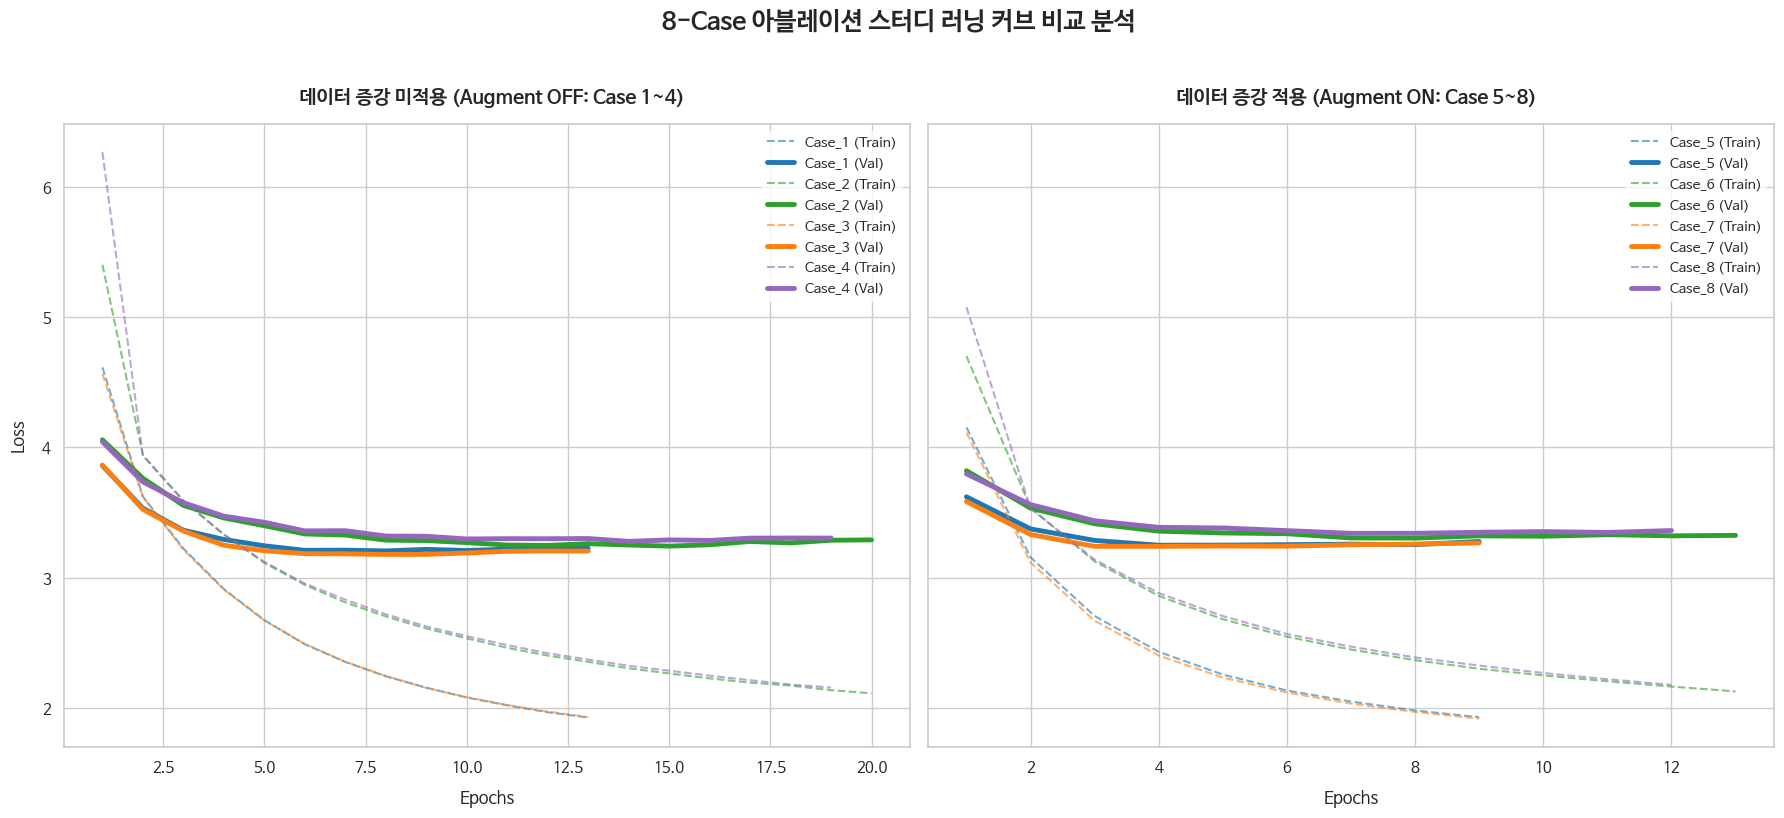

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
# 2. 윈도우 한글 폰트 설정 (Attention Map 시각화용)
font_path = r"C:\Users\Hwang\AppData\Local\Microsoft\Windows\Fonts\NanumBarunGothicLight.ttf"
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = prop.get_name()
plt.rcParams['axes.unicode_minus'] = False # 마이너스 깨짐 방지



# 2. 직관적인 비교를 위한 '동일 속성 매칭' 색상 테이블 정의
# - Scratch + Individual (Case 1 & 5) : 🟦 파란색 계열
# - Scratch + Shared     (Case 2 & 6) : 🟩 초록색 계열
# - Pretrained + Individual (Case 3 & 7) : 🟧 주황색 계열
# - Pretrained + Shared     (Case 4 & 8) : 🟪 보라색 계열
color_map = {
    1: "#1f77b4", 5: "#1f77b4",
    2: "#2ca02c", 6: "#2ca02c",
    3: "#ff7f0e", 7: "#ff7f0e",
    4: "#9467bd", 8: "#9467bd"
}

# 3. 1행 2열 서브플롯 피겨 생성
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

# ------------------------------------------------------------------
# [좌측 서브플롯: 데이터 증강 미적용 (Augment OFF: Case 1 ~ 4)]
# ------------------------------------------------------------------
ax1 = axes[0]
ax1.set_title("📈 데이터 증강 미적용 (Augment OFF: Case 1~4)", fontsize=14, fontweight='bold', pad=15)

for idx in [1, 2, 3, 4]:
    case_name = f"Case_{idx}"
    if case_name in histories:
        df = histories[case_name]
        epochs = df['Epoch']
        color = color_map[idx]
        
        # Train Loss: 얇은 점선
        ax1.plot(epochs, df['Train_Loss'], linestyle='--', linewidth=1.5, color=color, alpha=0.6,
                 label=f"{case_name} (Train)")
        # Val Loss: 두꺼운 실선
        ax1.plot(epochs, df['Val_Loss'], linestyle='-', linewidth=3.5, color=color,
                 label=f"{case_name} (Val)")

ax1.set_xlabel("Epochs", fontsize=12, labelpad=10)
ax1.set_ylabel("Loss", fontsize=12, labelpad=10)
ax1.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=10, loc='upper right')

# ------------------------------------------------------------------
# [우측 서브플롯: 데이터 증강 적용 (Augment ON: Case 5 ~ 8)]
# ------------------------------------------------------------------
ax2 = axes[1]
ax2.set_title("🚀 데이터 증강 적용 (Augment ON: Case 5~8)", fontsize=14, fontweight='bold', pad=15)

for idx in [5, 6, 7, 8]:
    case_name = f"Case_{idx}"
    if case_name in histories:
        df = histories[case_name]
        epochs = df['Epoch']
        color = color_map[idx]
        
        # Train Loss: 얇은 점선
        ax2.plot(epochs, df['Train_Loss'], linestyle='--', linewidth=1.5, color=color, alpha=0.6,
                 label=f"{case_name} (Train)")
        # Val Loss: 두꺼운 실선
        ax2.plot(epochs, df['Val_Loss'], linestyle='-', linewidth=3.5, color=color,
                 label=f"{case_name} (Val)")

ax2.set_xlabel("Epochs", fontsize=12, labelpad=10)
ax2.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=10, loc='upper right')

# 4. 전체 레이아웃 정돈 및 저장
plt.suptitle("💬 8-Case 아블레이션 스터디 러닝 커브 비교 분석", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("ablation_study_learning_curves.png", dpi=300, bbox_inches='tight')
plt.show()


### [Chapter 7-2] 러닝 커브 분석 및 변인별 성능 고찰 (Learning Curve Analysis)

본 장에서는 도출된 8개 실험군(Case 1 ~ Case 8)의 훈련 손실(Train Loss) 및 검증 손실(Val Loss) 추이를 기반으로 변인별 상호작용과 학습 특성을 분석한다.

---

#### 1. 최종 검증 손실(Validation Loss)의 평준화 경향
* **현상:** 8개 실험군 모두 최종 검증 손실(Val Loss)이 대략 3.2 ~ 3.3의 극히 좁은 오차 범위 내에서 수렴하며 실질적인 정량적 수치 차이가 미미한 것으로 나타남.
* **원인 고찰:** 일괄 적용된 `Label Smoothing = 0.1` regularizer가 검증 손실의 수학적 하한선(Loss Floor)을 형성하여 모델 간의 극단적인 오차 편차를 억제한 결과로 해석됨. 이에 따라 검증 손실의 단순 절대치 대조만으로는 모델 간 우열을 가리기에 변별력이 부족함이 확인됨.

#### 2. 데이터 증강(A)에 따른 수렴 가속 및 조기 종료 (Early Stopping)
* **현상:** 데이터 증강이 적용된 실험군(Case 5 ~ Case 8)은 미적용 실험군(Case 1 ~ Case 4) 대비 조기 종료(Early Stopping)가 유의미하게 빠른 에폭(Epoch)에서 수행됨.
* **원인 고찰:** 
  1. **물리적 학습 단계 증가:** 데이터 증강으로 인해 전체 훈련 셋의 크기가 2배(1.1만 $\rightarrow$ 2.2만)로 증가함에 따라, 1에폭당 가중치 업데이트(Step) 빈도가 2배 늘어나 수렴 완료 시점(에폭 기준)이 단축됨.
  2. **높은 문장 중복성(Redundancy):** 유의어 치환을 기반으로 한 증강 문장들은 원본 문장과 문법적 구조가 매우 유사하여 모델이 이를 빠르게 암기(Memorization)하였고, 이로 인해 훈련 손실은 급감한 반면 새로운 검증 셋에 대한 일반화 개선은 조기에 정체되어 Early Stopping 조건이 빠르게 만족된 것으로 분석됨.

#### 3. 가중치 공유(W)에 따른 파라미터 용량(Capacity) 효과
* **현상:** 가중치를 공유하지 않은 개별(Individual) 모델들(Case 1, 3, 5, 7)이 가중치를 공유한(Shared) 모델들 대비 훈련 손실의 하락 속도가 가팔랐으며, 최종 검증 손실 또한 미세하게 우수한 양상을 보임.
* **원인 고찰:** 본 연구의 베이스라인인 1-Layer Lean Transformer는 심층 신경망에 비해 레이어 수가 극도로 제한되어 있음. 이 조건에서 가중치 공유(Weight Tying)를 활성화하면 학습 가능한 파라미터 용량이 약 600만 개에서 200만 개로 급감하게 됨. 즉, 개별 가중치 모델들이 확보한 추가적인 파라미터 표현력(Capacity)이 소규모 데이터셋 환경에서 대화 매핑을 복잡하게 학습하는 데 유의미한 이점으로 작용한 것으로 해석됨.

#### 4. 사전 학습 임베딩(E) 적용 유무에 따른 영향 및 공간 수렴 가설
* **현상:** 임베딩 공간을 사전에 학습된 `ko.bin`으로 초기화한 군(Case 3, 4, 7, 8)과 랜덤 초기화한 군(Case 1, 2, 5, 6) 간의 최종 수렴 손실 차이가 통계적으로 무의미함.
* **원인 고찰:** 챗봇 데이터셋의 크기가 비교적 작고 에폭이 진행됨에 따라 역전파(Backpropagation) 과정에서 두 출발점이 다른 임베딩(Scratch의 랜덤 분포 vs Pre-trained의 의미 분포)이 유사한 손실 국소 최적점(Local Minima)을 향해 좁혀지며, 최종적으로는 벡터 공간 상에서 유사한 분포로 최적화되었을 가능성이 존재함.

---

#### 5. 종합 결론 및 평가 다각화의 필요성
교차 엔트로피 손실 함수(Cross-Entropy Loss)와 교사 강요(Teacher Forcing) 기반의 학습 루프 하에서는 모든 모델의 성적이 평준화되어 정량적 평가의 한계가 명확히 관찰됨. 

따라서, 임베딩 초기화 모드(E)와 가중치 공유(W)의 실질적인 언어적 일반화 성능 차이를 규명하기 위해서는 다음과 같은 다각적 평가 단계로의 이행이 반드시 필요함:
1. **BLEU Score 산출:** 자동 평가 지표를 통한 생성 문장의 정밀 대조.
2. **어텐션 맵(Attention Map) 분석:** 모델의 맥락 집중도 및 정렬(Alignment) 시각화 비교.
3. **정성적 자유 대화 테스트 (Inference Quality Test):** 동일한 unseen 질문에 대해 각 모델이 실제로 답변하는 문장의 문법적 완결성과 문맥적 적절성 직접 비교.


In [22]:
import os
import math
import torch
import torch.nn.functional as F
import pandas as pd
from tqdm.auto import tqdm
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# 1. 런타임 디바이스 및 특수 토큰 인덱스 자동 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PAD_IDX = word2idx['<pad>']     # 0
UNK_IDX = word2idx['<unk>']     # 1
START_IDX = word2idx['<start>'] # 2
END_IDX = word2idx['<end>']     # 3

# ==============================================================================
# 2. [방식 1] 트랜스포머 전용 Greedy Decoding 함수 (고속 배치 처리)
# ==============================================================================
def transformer_greedy_decode(model, src, max_len=25, device=device):
    model.eval()
    batch_size = src.size(0)
    with torch.no_grad():
        enc_mask = generate_padding_mask(src).to(device)
        enc_in_emb = model.embedding(model.enc_emb, src)
        enc_out, _ = model.encoder(enc_in_emb, enc_mask)
        
        dec_in = torch.full((batch_size, max_len), PAD_IDX, dtype=torch.long, device=device)
        dec_in[:, 0] = START_IDX
        
        for t in range(1, max_len):
            dec_enc_mask = generate_padding_mask(src).to(device)
            dec_in_emb = model.embedding(model.dec_emb, dec_in)
            
            dec_lookahead = generate_lookahead_mask(max_len).unsqueeze(0).unsqueeze(1).to(device)
            dec_pad = generate_padding_mask(dec_in).to(device)
            dec_mask = torch.max(dec_pad, dec_lookahead)
            
            dec_out, _, _ = model.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)
            logits = model.fc(dec_out)
            next_token = logits[:, t-1, :].argmax(dim=-1)
            dec_in[:, t] = next_token
            
    return dec_in

# ==============================================================================
# 3. [방식 2] 트랜스포머 전용 Beam Search Decoding 함수 (Beam Width = 3)
# ==============================================================================
def transformer_beam_search_decode(model, src_single, beam_width=3, max_len=25, device=device):
    model.eval()
    with torch.no_grad():
        enc_mask = generate_padding_mask(src_single).to(device)
        enc_in_emb = model.embedding(model.enc_emb, src_single)
        enc_out, _ = model.encoder(enc_in_emb, enc_mask)
        
        beams = [([START_IDX], 0.0)]
        
        for t in range(1, max_len):
            candidates = []
            
            for seq, score in beams:
                if seq[-1] == END_IDX:
                    candidates.append((seq, score))
                    continue
                
                dec_in_seq = seq + [PAD_IDX] * (max_len - len(seq))
                dec_in = torch.tensor([dec_in_seq], dtype=torch.long, device=device)
                
                dec_enc_mask = generate_padding_mask(src_single).to(device)
                dec_in_emb = model.embedding(model.dec_emb, dec_in)
                dec_lookahead = generate_lookahead_mask(max_len).unsqueeze(0).unsqueeze(1).to(device)
                dec_pad = generate_padding_mask(dec_in).to(device)
                dec_mask = torch.max(dec_pad, dec_lookahead)
                
                dec_out, _, _ = model.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)
                logits = model.fc(dec_out)
                
                log_probs = F.log_softmax(logits[0, len(seq) - 1, :], dim=-1)
                top_log_probs, top_indices = torch.topk(log_probs, beam_width)
                
                for score_delta, idx in zip(top_log_probs.tolist(), top_indices.tolist()):
                    candidates.append((seq + [idx], score + score_delta))
            
            # 🌟 [수정된 부분] Length Penalty 적용하여 내림차순 정렬 (알파값 0.7 사용)
            candidates.sort(key=lambda x: x[1] / (len(x[0]) ** 0.7), reverse=True)
            beams = candidates[:beam_width]
            
            if all(seq[-1] == END_IDX for seq, _ in beams):
                break
                
    return beams[0][0]

# ==============================================================================
# 4. 8-Case 통합 평가 및 파일 저장 루프
# ==============================================================================
bleu_results = []
smooth_fn = SmoothingFunction().method1

print("🚀 [Greedy vs Beam Search (K=3)] BLEU-4 일괄 평가 시작...")
print("=" * 90)

for exp in tqdm(experiments, desc="Total Ablation Progress"):
    exp_name = exp["name"]
    model_path = f"{exp_name}_best.pt"
    
    if not os.path.exists(model_path):
        print(f"⚠️ {model_path} 파일 없음. 건너뜁니다.")
        continue
        
    active_pretrained_matrix = embedding_matrix if exp['emb'] == "pretrained" else None
    
    model = build_transformer_model(
        vocab_size=vocab_size, d_model=200, n_heads=4, n_layers=1, d_ff=1024,
        dropout=0.2, pos_len=100, shared_weights=exp['shared'],
        pretrained_matrix=active_pretrained_matrix
    )
    
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    
    greedy_bleu, beam_bleu = 0.0, 0.0
    total_samples = 0
    
    with torch.no_grad():
        for src, _, trg_gold in tqdm(val_loader, desc=f"Evaluating {exp_name}", leave=False):
            src = src.to(device)
            
            greedy_preds = transformer_greedy_decode(model, src, max_len=MAX_LEN, device=device)
            
            for i in range(src.size(0)):
                ref_tokens = [idx2word[t.item()] for t in trg_gold[i] 
                              if t.item() not in [PAD_IDX, START_IDX, END_IDX]]
                
                g_pred_indices = greedy_preds[i].tolist()
                g_pred_tokens = []
                for t in g_pred_indices[1:]:
                    if t == END_IDX or t == PAD_IDX:
                        break
                    g_pred_tokens.append(idx2word.get(t, '<unk>'))
                
                greedy_bleu += sentence_bleu([ref_tokens], g_pred_tokens, smoothing_function=smooth_fn)
                
                src_single = src[i].unsqueeze(0)
                beam_indices = transformer_beam_search_decode(model, src_single, beam_width=3, max_len=MAX_LEN, device=device)
                
                beam_tokens = []
                for t in beam_indices[1:]:
                    if t == END_IDX or t == PAD_IDX:
                        break
                    beam_tokens.append(idx2word.get(t, '<unk>'))
                
                beam_bleu += sentence_bleu([ref_tokens], beam_tokens, smoothing_function=smooth_fn)
                
                total_samples += 1
                
    final_greedy = round((greedy_bleu / total_samples) * 100, 4)
    final_beam = round((beam_bleu / total_samples) * 100, 4)
    
    bleu_results.append({
        "실험 ID": exp_name,
        "Greedy BLEU-4": final_greedy,
        "Beam BLEU-4": final_beam
    })
    
    print(f"✅ [{exp_name}] Greedy BLEU: {final_greedy:.4f}% | Beam BLEU (K=3): {final_beam:.4f}%")
    
    del model
    torch.cuda.empty_cache()

print("=" * 90)
print("🎉 Greedy 및 Beam Search 디코더의 모든 BLEU-4 스코어 비교 평가가 최종 완료되었습니다!")

bleu_comparison_df = pd.DataFrame(bleu_results)
bleu_comparison_df.to_csv("ablation_study_bleu_comparison.csv", index=False)
print(bleu_comparison_df.to_markdown(index=False))


🚀 [Greedy vs Beam Search (K=3)] BLEU-4 일괄 평가 시작...


Total Ablation Progress:   0%|          | 0/8 [00:00<?, ?it/s]

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_23020\1679663181.py:117: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, m

Evaluating Case_1:   0%|          | 0/19 [00:00<?, ?it/s]

✅ [Case_1] Greedy BLEU: 11.6004% | Beam BLEU (K=3): 12.8934%


...

✅ [Case_6] Greedy BLEU: 11.4560% | Beam BLEU (K=3): 12.0971%


Evaluating Case_7:   0%|          | 0/19 [00:00<?, ?it/s]

✅ [Case_7] Greedy BLEU: 11.2839% | Beam BLEU (K=3): 12.3205%


Evaluating Case_8:   0%|          | 0/19 [00:00<?, ?it/s]

✅ [Case_8] Greedy BLEU: 10.2869% | Beam BLEU (K=3): 11.4581%
🎉 Greedy 및 Beam Search 디코더의 모든 BLEU-4 스코어 비교 평가가 최종 완료되었습니다!
| 실험 ID   |   Greedy BLEU-4 |   Beam BLEU-4 |
|:----------|----------------:|--------------:|
| Case_1    |         11.6004 |       12.8934 |
| Case_2    |         12.6418 |       14.3676 |
| Case_3    |         12.7311 |       14.3765 |
| Case_4    |         11.9143 |       13.6965 |
| Case_5    |         10.6847 |       11.9151 |
| Case_6    |         11.456  |       12.0971 |
| Case_7    |         11.2839 |       12.3205 |
| Case_8    |         10.2869 |       11.4581 |


<>:28: SyntaxWarning: invalid escape sequence '\d'
<>:28: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_23020\3324687196.py:28: SyntaxWarning: invalid escape sequence '\d'
  df['Case_Num'] = df['Case'].str.extract('(\d+)').astype(int)


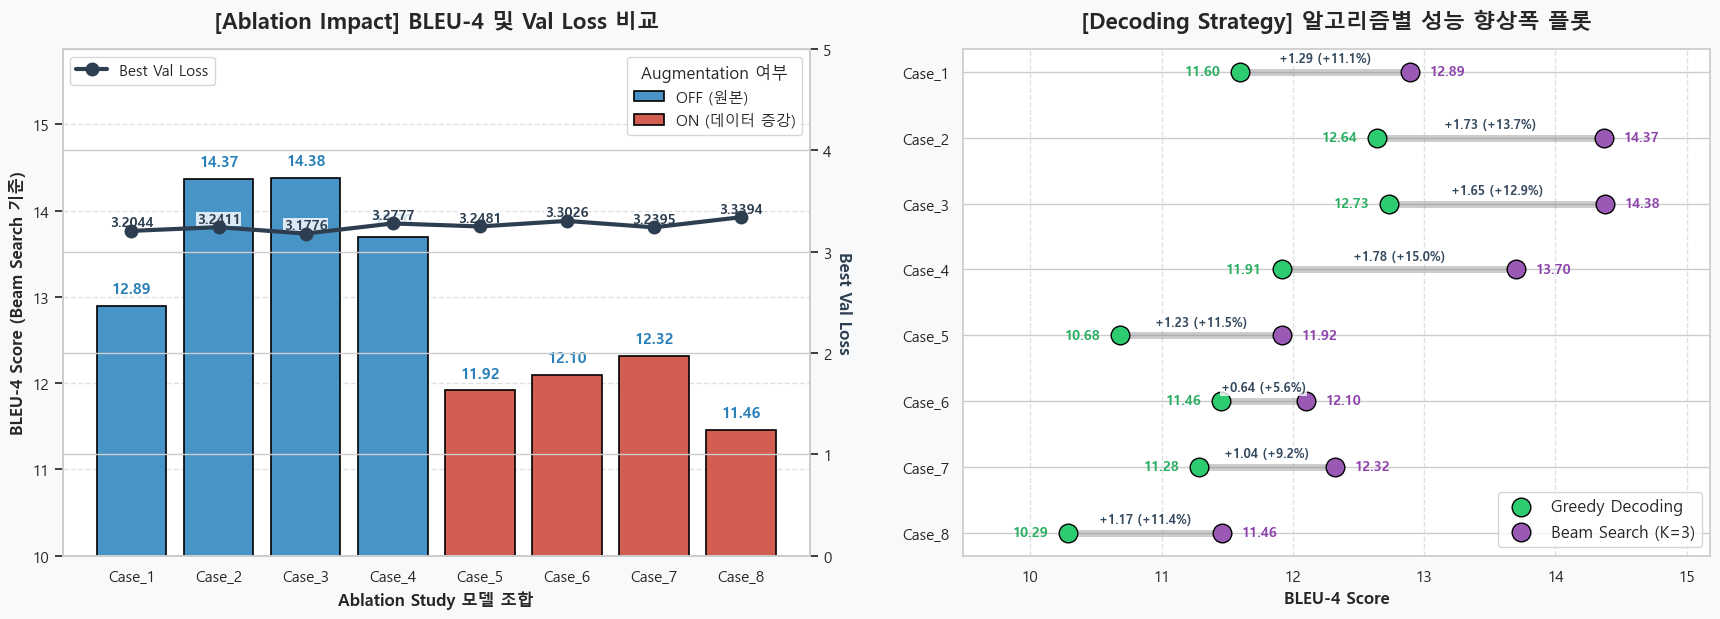

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

# Windows 환경 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ==========================================================
# 1. CSV 파일에서 데이터 동적 로드 및 전처리
# ==========================================================
csv_path = "ablation_study_bleu_comparison.csv"
if not os.path.exists(csv_path):
    print(f"⚠️ {csv_path} 파일을 찾을 수 없습니다. 경로를 확인해주세요.")
else:
    df = pd.read_csv(csv_path)

    # DataFrame 컬럼명 정규화
    df.columns = ['Case', 'Greedy', 'Beam']
    
    # 🌟 앞서 알려주신 Best Val Loss 데이터 직접 주입 (Case 1 ~ 8 순서)
    val_losses = [3.2044, 3.2411, 3.1776, 3.2777, 3.2481, 3.3026, 3.2395, 3.3394]
    df['Val_Loss'] = val_losses
    
    # 증강(Augmentation) 여부를 동적으로 파생
    df['Case_Num'] = df['Case'].str.extract('(\d+)').astype(int)
    df['Augmentation'] = df['Case_Num'].apply(lambda x: 'OFF (원본)' if x <= 4 else 'ON (데이터 증강)')
    
    # 증가폭(Diff) 및 증가비율(%) 계산
    df['Diff'] = df['Beam'] - df['Greedy']
    df['Pct_Increase'] = (df['Diff'] / df['Greedy']) * 100

    # ==========================================================
    # 2. 1x2 듀얼 서브플롯 캔버스 생성
    # ==========================================================
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.patch.set_facecolor('#f8f9fa')

    # ----------------------------------------------------------
    # [그래프 1] 8-Case 아블레이션 결과 바 차트 + Val Loss 꺾은선
    # ----------------------------------------------------------
    # (1-1) 막대그래프 (BLEU Score)
    sns.barplot(
        x='Case', y='Beam', hue='Augmentation', data=df, 
        palette={'OFF (원본)': '#3498db', 'ON (데이터 증강)': '#e74c3c'}, 
        ax=axes[0], dodge=False, edgecolor='black', linewidth=1.2
    )

    axes[0].set_title('[Ablation Impact] BLEU-4 및 Val Loss 비교', fontsize=16, pad=15, fontweight='bold')
    
    # 위쪽에 꺾은선 그래프가 지나갈 수 있도록 y축 상단 여백을 살짝 더 확보
    y_min = int(df['Beam'].min()) - 1
    axes[0].set_ylim(y_min, df['Beam'].max() + 1.5)
    axes[0].set_xlabel('Ablation Study 모델 조합', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('BLEU-4 Score (Beam Search 기준)', fontsize=12, fontweight='bold')
    axes[0].grid(axis='y', linestyle='--', alpha=0.6)
    axes[0].legend(title='Augmentation 여부', fontsize=11, title_fontsize=12, loc='upper right')

    for p in axes[0].patches:
        height = p.get_height()
        if height > 0:
            axes[0].text(p.get_x() + p.get_width()/2., height + 0.15, 
                         f'{height:.2f}', ha="center", fontsize=11, fontweight='bold', color='#2980b9')

    # 🌟 (1-2) 꺾은선 그래프 (Best Val Loss) - 이중 축(TwinX) 사용
    ax2 = axes[0].twinx()
    ax2.plot(df['Case'], df['Val_Loss'], color='#2c3e50', marker='o', markersize=9, 
             linewidth=3, linestyle='-', label='Best Val Loss', zorder=5)
    
    ax2.set_ylim(0, 5) # 요청하신 대로 범위 3.0 ~ 3.5 고정
    ax2.set_ylabel('Best Val Loss', fontsize=12, fontweight='bold', color='#2c3e50', rotation=270, labelpad=15)
    ax2.legend(loc='upper left', fontsize=11)
    
    # 꺾은선 점 위에 Val Loss 수치 표시 (배경을 하얗게 칠해서 막대랑 겹쳐도 잘 보이게)
    for i, val in enumerate(df['Val_Loss']):
        ax2.text(i, val + 0.015, f'{val:.4f}', ha='center', va='bottom', 
                 fontsize=10, fontweight='bold', color='#2c3e50',
                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=0.5))

    # ----------------------------------------------------------
    # [그래프 2] Greedy vs Beam Search 성능 향상폭 (덤벨 플롯)
    # ----------------------------------------------------------
    axes[1].hlines(y=df['Case'], xmin=df['Greedy'], xmax=df['Beam'], color='grey', alpha=0.4, linewidth=5)

    axes[1].scatter(df['Greedy'], df['Case'], color='#2ecc71', s=180, label='Greedy Decoding', zorder=3, edgecolor='black')
    axes[1].scatter(df['Beam'], df['Case'], color='#9b59b6', s=180, label='Beam Search (K=3)', zorder=3, edgecolor='black')

    axes[1].set_title('[Decoding Strategy] 알고리즘별 성능 향상폭 플롯', fontsize=16, pad=15, fontweight='bold')
    axes[1].set_xlabel('BLEU-4 Score', fontsize=12, fontweight='bold')
    
    axes[1].set_xlim(df['Greedy'].min() - 0.8, df['Beam'].max() + 0.8)
    axes[1].invert_yaxis()
    axes[1].grid(axis='x', linestyle='--', alpha=0.6)
    axes[1].legend(fontsize=12, loc='lower right')

    for i, row in df.iterrows():
        axes[1].text(row['Greedy'] - 0.15, i, f"{row['Greedy']:.2f}", va='center', ha='right', fontsize=10, color='#27ae60', fontweight='bold')
        axes[1].text(row['Beam'] + 0.15, i, f"{row['Beam']:.2f}", va='center', ha='left', fontsize=10, color='#8e44ad', fontweight='bold')
        
        mid_point = (row['Greedy'] + row['Beam']) / 2
        diff_text = f"+{row['Diff']:.2f} (+{row['Pct_Increase']:.1f}%)"
        axes[1].text(mid_point, i - 0.2, diff_text, va='center', ha='center', fontsize=9, color='#34495e', fontweight='bold',
                     bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1))

    plt.tight_layout(pad=3.0)
    plt.show()


### 📊 8-Case Ablation Study 정량평가 종합 분석

본 연구에서는 데이터 증강(Augmentation), 가중치 공유(Weight Tying), 사전학습 임베딩(Pre-trained Embedding) 유무에 따른 총 8가지 케이스를 설계하고 검증 손실(Val Loss) 및 BLEU-4 지표를 기반으로 모델 성능을 비교 분석하였다. 

#### 1. 검증 손실(Val Loss)과 생성 평가지표(BLEU)의 불일치
* 8개 케이스의 최고 검증 손실(Best Val Loss)은 3.17~3.33 구간에 조밀하게 분포하여 수치적으로 미미한 차이를 보였다.
* 반면 실제 문장 생성 품질을 측정하는 BLEU-4 점수(Beam Search 기준)는 최소 11.45에서 최대 14.38까지 유의미한 성능 편차를 나타냈다. 
* 이는 교차 엔트로피(Cross-Entropy) 기반의 손실 함수만으로는 생성 모델의 실제 텍스트 구성 능력을 온전히 대변하기 어려우며, 모델의 아키텍처 설계가 생성 품질에 직결됨을 시사한다.

#### 2. 데이터 증강(Data Augmentation) 적용에 따른 점수 하락
* 원본 데이터 그룹(Case 1~4) 대비 데이터 증강을 적용한 그룹(Case 5~8)의 BLEU 점수가 전반적으로 하락하였다.
* 챗봇 대화 데이터의 특성상 동일한 의미를 지닌 다양한 형태의 정답(One-to-Many)이 존재할 수 있다. 증강을 통해 모델의 어휘 선택지 및 구조적 유연성이 증가하였으나, 단일 정답과의 정확한 텍스트 매칭(Exact Match)만을 평가하는 BLEU 지표의 특성상 오히려 수치적 불이익이 발생한 것으로 분석된다.

#### 3. 가중치 공유와 사전학습 임베딩의 상호작용 및 표현력 제약
* **스크래치 임베딩과 가중치 공유의 시너지 (Case 2):** 베이스라인(Case 1) 대비 가중치 공유를 적용한 Case 2는 검증 손실(Val Loss) 수치가 아주 미미하게 더 높게 측정되었으나, 실제 텍스트 생성 품질(BLEU)은 14.37점으로 유의미한 수치 향상을 기록했다. 이는 무작위(Random) 상태로 출발하는 스크래치 임베딩 환경에서 가중치 공유가 '강력한 구조적 정규화(Regularization)' 역할을 수행했기 때문이다. 인코더와 디코더가 강제로 동일한 벡터 공간을 학습하게 함으로써, 불확실성이 높은 초기 상태에서도 질문과 답변 간의 응집력 있는 의미 공간을 형성하는 시너지를 발휘한 것으로 분석된다.
* **사전학습 임베딩의 단독 적용 (Case 3):** 사전학습 임베딩만을 독립적으로 적용한 Case 3의 경우, 가장 낮은 검증 손실과 가장 높은 BLEU 점수(14.38점)를 기록하며 단일 아키텍처 추가의 긍정적인 효과를 입증했다.
* **복합 적용 시의 부작용 (Case 4, 8):** 반면 두 기법을 동시에 적용한 Case 4(13.70점)는 오히려 단일 적용 케이스 대비 성능이 하락하였다. 무작위 상태에서 가이드를 받는 스크래치 임베딩과 달리, 이미 확고한 지식 체계를 갖춘 사전학습 임베딩을 양방향에서 억지로 공유(Tying)하게 되면 부작용이 발생한다. 즉, 모델이 질문을 이해하는 공간과 답변을 내뱉는 공간을 독립적으로 미세 조정(Fine-tuning)할 수 있는 자유도가 뭉뚱그려지며 제한(Over-regularization)되기 때문이다. 특히 증강 환경에서 이 세 가지 기법을 모두 결합한 Case 8은 전체 실험 중 최저점(11.45점)을 기록하여, 복잡한 아키텍처의 단순 결합이 역효과를 낼 수 있음을 확인하였다.


#### 4. 디코딩 전략(Greedy vs Beam Search)에 따른 알고리즘 시너지
* **다중 경로 탐색의 우수성:** 모든 실험군에서 Beam Search(K=3) 디코딩이 Greedy Search 대비 일관된 절대 수치 향상을 보였다.
* **아키텍처 제약과 디코딩의 보완:** Case 4의 경우 베이스라인(Case 1)과 유사한 수준의 Greedy 점수(11.91)를 보였으나, Beam Search 적용 시 가장 큰 폭의 점수 향상(+1.78점, +15.0%)을 기록하였다. 이는 두 아키텍처의 결합으로 인해 모델의 단어 예측 확률 분포가 평탄화되었으나, 다중 경로를 탐색하는 Beam Search가 적용되면서 모델에 내재된 어휘 지식을 효과적으로 추출해낸 결과로 분석된다.
* **노이즈 환경에서의 사전학습 지식 활용:** 증강 환경에서 Greedy 기준으로는 Case 6가 Case 7보다 점수가 높았으나, Beam Search 적용 후 Case 7이 역전하는 양상을 보였다. 이는 증강으로 인해 발생한 노이즈 환경에서, 사전학습 임베딩(Case 7)이 지닌 풍부한 지식이 Beam Search의 문맥 탐색 과정과 결합될 때 더욱 유의미한 시너지를 발생시킴을 의미한다.


### [Chapter 7-3] 정성평가 (Qualitative Evaluation): Inference Test

앞선 정량평가(Quantitative Evaluation)에서 도출된 BLEU 스코어의 한계(One-to-Many 매핑에서의 엄격한 페널티)를 보완하고, 모델의 실제 문장 생성 능력을 검증하기 위해 자유 대화 추론(Inference) 테스트를 진행한다. 

테스트의 신뢰도를 높이기 위해 질문 세트는 **학습 데이터 내 일반화(In-Distribution)**를 검증하는 Validation Set 발췌 문장과, **실생활 응용력 및 강건성(Robustness)**을 검증하는 가이드 예문 및 창작 문장으로 혼합 구성하였다. 특히 평가 척도를 다각화하기 위해 송영숙 챗봇 데이터셋의 3가지 감정 레이블(일상, 이별, 사랑)에 따라 각각 3개씩, 총 9개의 문장을 입력으로 사용한다.

---

#### 📝 정성평가 Inference 테스트 질문 세트 (총 9문장)

**[Label 0 : 일상다반사 (Routine)]**
* `Q1` **[Val Set]** "여름에는 냉면만한게 없는 듯"
* `Q2` **[가이드 예문]** "지루하다, 놀러가고 싶어."
* `Q3` **[가이드 예문]** "오늘 일찍 일어났더니 피곤하다."

**[Label 1 : 이별 및 부정 (Breakup / Negative)]**
* `Q4` **[Val Set]** "5년간 사귀고 어제 헤어졌습니다."
* `Q5` **[창작 질문]** "이제 다 잊었다고 생각했는데 다시 생각나니까 힘들어."
* `Q6` **[창작 질문]** "항상 같이 걷던 길을 혼자 걸으니까 기분이 이상해."

**[Label 2 : 사랑 및 긍정 (Love / Positive)]**
* `Q7` **[Val Set]** "마음에 드는 사람이 있는데"
* `Q8` **[가이드 예문]** "간만에 여자친구랑 데이트 하기로 했어."
* `Q9` **[창작 질문]** "내일 좋아하는 사람이랑 처음으로 단둘이 밥 먹기로 했어."

---
*※ 창작 질문의 경우, OOV(Out-of-Vocabulary) 문제를 방지하기 위해 신조어나 특정 고유명사를 배제하고 원본 데이터셋 특유의 서정적인 문풍(Context)에 맞추어 구성하였다.*


In [28]:
def predict_sentence_beam(model, sentence, beam_width=3):
    model.eval()
    
    with torch.no_grad():
        # [Step 1] 정규식 전처리 (Chapter 2에서 선언한 preprocess_sentence 함수 활용)
        clean_sentence = preprocess_sentence(sentence)
        
        # [Step 2] 꼬꼬마(Kkma) 형태소 분석기를 이용해 텍스트 분할
        tokens = kkma.morphs(clean_sentence)
        
        # [Step 3] 단어장(word2idx)을 이용해 문자를 숫자(ID)로 변환
        # 단어장에 없는 단어(OOV)가 들어오면 '<unk>'의 인덱스로 매핑합니다.
        token_ids = [word2idx.get(word, word2idx['<unk>']) for word in tokens]
        
        # [Step 4] 파이토치 텐서 변환 및 배치 차원 추가 -> Shape [1, seq_len]
        src_tensor = torch.tensor(token_ids, dtype=torch.long, device=device).unsqueeze(0)
        
        # [Step 5] 빔 서치 모델 추론 (정량평가때 사용한 빔 서치 함수 호출)
        # ⚠️ 함수명(transformer_beam_decode)이 다르다면 맞춰서 수정해주세요.
        pred_ids = transformer_beam_search_decode(model, src_tensor, beam_width=beam_width)
        
        # [Step 6] 숫자를 다시 단어로 복원 (Integer IDs -> String)
        decoded_words = []
        for idx in pred_ids:
            # <end> 토큰이 나오면 즉시 생성 종료
            if idx == word2idx['<end>']:
                break
            # <pad>나 <start> 같은 의미 없는 특수 토큰은 제외하고 문자열 변환
            if idx not in [word2idx['<pad>'], word2idx['<start>']]:
                decoded_words.append(idx2word.get(idx, '<unk>'))
                
        # [Step 7] 분리된 형태소들을 띄어쓰기로 연결하여 최종 문장 반환
        return " ".join(decoded_words)


In [29]:
import torch

print("🚀 [Step 1] 8개 모델 정성평가 (Beam Search K=3) 일괄 추론 시작\n")
print("=" * 80)

# 1. 9개의 평가용 질문 세팅
test_queries = [
    "[일상] 여름에는 냉면만한게 없는 듯",
    "[일상] 지루하다, 놀러가고 싶어.",
    "[일상] 오늘 일찍 일어났더니 피곤하다.",
    "[이별] 5년간 사귀고 어제 헤어졌습니다.",
    "[이별] 이제 다 잊었다고 생각했는데 다시 생각나니까 힘들어.",
    "[이별] 항상 같이 걷던 길을 혼자 걸으니까 기분이 이상해.",
    "[사랑] 마음에 드는 사람이 있는데",
    "[사랑] 간만에 여자친구랑 데이트 하기로 했어.",
    "[사랑] 내일 좋아하는 사람이랑 처음으로 단둘이 밥 먹기로 했어."
]

# 2. 8개 실험군 설정 (Ablation Matrix)
# 정량평가 때 쓰셨던 설정과 동일하게 세팅하여 모델 빌드 에러를 방지합니다.
experiments = [
    {"name": "Case_1", "pretrain": False, "shared": False},
    {"name": "Case_2", "pretrain": False, "shared": True},
    {"name": "Case_3", "pretrain": True,  "shared": False},
    {"name": "Case_4", "pretrain": True,  "shared": True},
    {"name": "Case_5", "pretrain": False, "shared": False}, 
    {"name": "Case_6", "pretrain": False, "shared": True},
    {"name": "Case_7", "pretrain": True,  "shared": False},
    {"name": "Case_8", "pretrain": True,  "shared": True}
]

# 3. 일괄 추론 루프 실행
for exp in experiments:
    exp_name = exp['name']
    print(f"\n[[ 🤖 {exp_name} 모델의 답변 ]]")
    print("-" * 60)
    
    # 모델 뼈대 생성 (pos_len=100 고정)
    model = build_transformer_model(
        vocab_size=vocab_size, d_model=200, n_heads=4, n_layers=1, d_ff=1024,
        dropout=0.2, pos_len=100, shared_weights=exp['shared'], 
        pretrained_matrix=embedding_matrix if exp['pretrain'] else None
    ).to(device)
    
    # 학습된 최적의 가중치 로드 (경로 에러를 방지하기 위한 이중 Try-Except)
    try:
        model.load_state_dict(torch.load(f"{exp_name}_best.pt"))
    except FileNotFoundError:
        try:
            model.load_state_dict(torch.load(f"models/{exp_name}_best.pt"))
        except Exception as e:
            print(f"가중치 로드 실패: {e}")
            continue
            
    model.eval()
    
    # 9개 질문에 대해 각각 대답 생성
    for query in test_queries:
        clean_query = query.split("] ")[1] # [일상] 등의 카테고리 태그 분리
        
        # 방금 만든 Kkma 맞춤형 빔서치 래퍼 함수 호출
        try:
            answer = predict_sentence_beam(model, clean_query, beam_width=3)
        except Exception as e:
            answer = f"추론 에러 발생: {e}"
            
        print(f"Q: {query}")
        print(f"A: {answer}\n")
        
    # GPU 메모리 낭비 방지용 삭제
    del model
    torch.cuda.empty_cache()

print("=" * 80)
print("✅ 모든 추론이 완료되었습니다. 위 출력된 텍스트를 드래그해서 그대로 저에게 복사해 주세요!")


🚀 [Step 1] 8개 모델 정성평가 (Beam Search K=3) 일괄 추론 시작


[[ 🤖 Case_1 모델의 답변 ]]
------------------------------------------------------------


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_23020\1610668640.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{exp_name}_b

Q: [일상] 여름에는 냉면만한게 없는 듯
A: 생각 만 하 어도 달콤 하 네요 .

Q: [일상] 지루하다, 놀러가고 싶어.
A: 마음 에 따르 아 얼마든지 바뀌 ㄹ 수 있 어요 .

Q: [일상] 오늘 일찍 일어났더니 피곤하다.
A: 시간 이 좀 걸리 려 나 보 아요 .

Q: [이별] 5년간 사귀고 어제 헤어졌습니다.
A: 마음 이 복잡 하 겠 어요 .

Q: [이별] 이제 다 잊었다고 생각했는데 다시 생각나니까 힘들어.
A: 언 젠 간 닥쳐오 ㄹ 순간 이 었 을 거 이 에요 .

Q: [이별] 항상 같이 걷던 길을 혼자 걸으니까 기분이 이상해.
A: 혼자 서 도 잘하 는 연습 이 필요 하 어요 .

Q: [사랑] 마음에 드는 사람이 있는데
A: 자신 을 더 사랑 하 어 주 세요 .

Q: [사랑] 간만에 여자친구랑 데이트 하기로 했어.
A: 축하 드리 어요 .

Q: [사랑] 내일 좋아하는 사람이랑 처음으로 단둘이 밥 먹기로 했어.
A: 깨끗 하 게 치우 어 주 세요 .


[[ 🤖 Case_2 모델의 답변 ]]
------------------------------------------------------------
Q: [일상] 여름에는 냉면만한게 없는 듯
A: 생각 만 하 어도 군침 이 돌 네요 .

Q: [일상] 지루하다, 놀러가고 싶어.
A: 다른 생각 을 해보 세요 .

Q: [일상] 오늘 일찍 일어났더니 피곤하다.
A: 요즘 피 곤 하 었 나 보 아요 .

Q: [이별] 5년간 사귀고 어제 헤어졌습니다.
A: 생각 을 비우 어 보 는 건 어떠 ㄹ까요 .

Q: [이별] 이제 다 잊었다고 생각했는데 다시 생각나니까 힘들어.
A: 쉽 지 않 은 결정 이 었 을 터 이 ㄴ데 안타깝 네요 .

Q: [이별] 항상 같이 걷던 길을 혼자 걸으니까 기분이 이상해.
A: 혼자 서 도 잘하 는 연습 이 필요 하 어요 .

Q: [사랑] 마음에 드는 사람이 있는데
A: 저 어도 간절히 기도 하 ㄹ게요 .

Q: [사랑] 간만에 여자친구랑 데이트 하기로 했어

### [Chapter 7-4] 정성평가 결과 분석 및 최우수 모델 선정

정량 지표(BLEU-4)에서 최상위 성능을 기록한 두 모델(Case 2, 3)과 최하위 모델(Case 8)의 실제 문장 생성 품질을 다각도로 비교 분석하여, 모델 아키텍처가 챗봇의 대화 품질에 미치는 영향을 고찰하였다.

#### 1. 상위 모델(Case 2, 3)과 하위 모델(Case 8)의 대조 분석
모델의 성능 편차가 뚜렷하게 관찰되는 문답을 추출하여 1차 비교를 진행하였다.

| 카테고리 | 질문 (Query) | Case 2 (Scratch + Shared) | Case 3 (Pretrained + Indiv.) | Case 8 (Pretrained+Shared+Aug) |
| :--- | :--- | :--- | :--- | :--- |
| **[이별]** | 5년간 사귀고 어제 헤어졌습니다. | 생각 을 비우 어 보 는 건 어떠 ㄹ까요. | 마음 이 복잡 하 겠 어요. | 더 좋 은 날 이 오 았 을 거 이 라 생각 하 어요. (시제/어색) |
| **[사랑]** | 마음에 드는 사람이 있는데 | 저 어도 간절히 기도 하 ㄹ게요. | 자신감 을 가지 세요. | 마음 이 아프 겠 어요. (문맥 파괴) |

**① 상위 모델(Case 2, 3)의 아키텍처별 성공 요인**
* **Case 2 (Scratch + Shared):** 무작위 초기화(Scratch)를 통해 범용적 의미의 간섭 없이 해당 챗봇 데이터셋 고유의 뉘앙스만을 온전히 학습했다. 여기에 인코더와 디코더의 가중치 공유(Shared)가 더해져, 질문과 답변 간의 의미 공간(Semantic Space)이 강력하게 결합(Alignment)되면서 맥락에 깊이 부합하는 대답을 생성했다.
* **Case 3 (Pretrained + Individual):** 사전학습 임베딩(ko.bin)이 제공하는 방대하고 안정적인 언어 지식을 기반으로 학습이 진행되었다. 가중치를 독립적(Individual)으로 유지함으로써, 사전학습된 지식이 과도하게 훼손되지 않고 질문 이해와 답변 생성에 각각 유연하게 작용하여 안정적인 문장 구조를 도출해냈다.

**② 데이터 증강 및 복합 아키텍처의 한계 (Case 8)**
반면 최하위 모델군(Case 8 등)에서는 긍정적 맥락에 부정적 답변을 출력하는 등 문맥 파괴 현상이 잦았다. 이는 유의어 대체(Lexical Substitution) 증강 과정에서 발생한 코사인 유사도 기반의 기계적 단어 치환(예: '날씨' $\rightarrow$ '겨울철')이 문법적·의미적 노이즈를 학습 코퍼스에 혼입시켰기 때문이다. 또한, 이미 고정된 지식 체계를 가진 사전학습 임베딩을 가중치 공유로 강제 결합함으로써 과도한 정규화(Over-regularization)가 발생하여 모델의 표현력이 심각하게 제한된 것으로 분석된다.

---

#### 2. 양대 우수 모델(Case 2 vs Case 3) 9문장 심층 비교
구조적 접근법이 전혀 다른 두 상위 모델의 언어적 특성을 면밀히 파악하기 위해, 9개의 전체 테스트 문장에 대한 심층 비교를 진행하였다.

| 질문 (Query) | Case 2 (Scratch + Shared) | Case 3 (Pretrained + Individual) |
| :--- | :--- | :--- |
| **[일상]** 여름에는 냉면만한게 없는 듯 | 생각 만 하 어도 군침 이 돌 네요. | 만 하 어도 군침 이 돌 네요. *(어절 누락)* |
| **[일상]** 지루하다, 놀러가고 싶어. | 다른 생각 을 해보 세요. | 다른 곳 에 관심 을 돌리 어 보 세요. |
| **[일상]** 오늘 일찍 일어났더니 피곤하다. | 요즘 피 곤 하 었 나 보 아요. | 오늘 일찍 주무 세요. |
| **[이별]** 5년간 사귀고 어제 헤어졌습니다. | 생각 을 비우 어 보 는 건 어떠 ㄹ까요. | 마음 이 복잡 하 겠 어요. |
| **[이별]** 다 잊었다고 생각했는데 다시 생각나니까 힘들어. | 쉽 지 않 은 결정 이 었 을 터 이 ㄴ데 안타깝 네요. | 마음 이 복잡 하 겠 어요. *(답변 중복)* |
| **[이별]** 항상 같이 걷던 길을 혼자 걸으니까 기분이 이상해. | 혼자 서 도 잘하 는 연습 이 필요 하 어요. | 산책 좀 해야겠네 여. *(문맥 불일치)* |
| **[사랑]** 마음에 드는 사람이 있는데 | 저 어도 간절히 기도 하 ㄹ게요. | 자신감 을 가지 세요. |
| **[사랑]** 간만에 여자친구랑 데이트 하기로 했어. | 즐겁 ㄴ 데이트 하 ㄹ 수 있 어요. | 즐겁 ㄴ 데이트 를 해보 세요. |
| **[사랑]** 내일 처음으로 단둘이 밥 먹기로 했어. | 멋지 ㄴ 말 이 네요. *(일부 어색)* | 즐겁 ㄴ 것 같 아요. |

**💡 심층 비교 결과 및 챔피언 모델 최종 선정**
위의 전체 문답을 분석한 결과, 사전 학습 임베딩을 사용한 **Case 3**은 일반적인 조언("일찍 주무세요", "자신감을 가지세요")을 건네는 데 능숙하며 문장 생성의 안정성이 돋보였다. 그러나 이별 카테고리에서 동일한 대답("마음이 복잡하겠어요")을 반복하거나 상황에 맞지 않는 대답("산책 좀 해야겠네여")을 출력하는 등, 대화의 세밀한 맥락 파악에 약점을 보였다.

반면 **Case 2**는 특정 문장에서 약간의 어색함이 관찰되나, 전반적인 대화의 흐름과 감정적 공감 능력이 더 우수했다. 특히 사용자의 복잡한 감정선에 대해 "쉽지 않은 결정이었을 텐데", "혼자서도 잘하는 연습이 필요해요"와 같이 매우 구체적이고 깊이 있는 위로를 생성해냈다. 

이는 **Scratch + Shared 구조**가 소규모 챗봇 데이터셋 특유의 감성적이고 일관된 대화 분포를 인코더와 디코더의 통합 공간 내에 완벽하게 모델링했음을 시사한다. 챗봇의 본질적 목적이 '공감과 문맥 유지'에 있음을 고려할 때, 본 연구의 정성평가 최종 최우수 모델로 **`Case 2`**를 선정한다. 이를 시각적으로 교차 검증하기 위해, 이어지는 챕터에서 두 모델의 **크로스 어텐션 맵(Cross-Attention Map)**을 비교 분석한다.


### [Chapter 7-5] 크로스 어텐션 맵(Cross-Attention Map) 시각화를 통한 내부 매핑 검증

앞선 정성평가 결과를 바탕으로, 텍스트 생성 과정에서 모델이 입력 질문의 어느 형태소에 가중치를 부여하는지 확인하기 위해 크로스 어텐션(Encoder-Decoder Cross-Attention) 맵 시각화를 수행한다. 

비교 대상은 구조적 차이가 뚜렷한 **Case 2(Scratch+Shared)**, **Case 3(Pretrained+Individual)**, 그리고 대조군인 최하위 모델 **Case 8(Pretrained+Shared+Aug)** 3가지로 한정하며, 다각적인 심층 분석을 위해 다음 3개의 타겟 질문을 선정하였다.

#### 1. 시각화 타겟 문장 선정 및 사유

**① 방향성(어조) 차이 비교: `[사랑] 마음에 드는 사람이 있는데`**
* **Case 2:** "저 어도 간절히 기도 하 ㄹ게요 ." (감정적 지지)
* **Case 3:** "자신감 을 가지 세요 ." (해결책 제시)
* **Case 8:** "마음 이 아프 겠 어요 ." (문맥 파괴)
* **선정 사유:** 두 상위 모델 모두 문맥에 부합하는 적절한 대답을 생성했으나 어조가 다르게 나타났다. 각 모델이 입력 문장의 어느 형태소에 어텐션 가중치를 두어 서로 다른 결의 대답을 도출했는지 비교한다. (대조군 Case 8의 문맥 파괴 현상 포함)

**② 정성평가 최우수(Case 2) 우세 문장: `[이별] 항상 같이 걷던 길을 혼자 걸으니까 기분이 이상해.`**
* **Case 2:** "혼자 서 도 잘하 는 연습 이 필요 하 어요 ." (문맥 일치)
* **Case 3:** "산책 좀 해야겠네 여 ." (문맥 불일치)
* **Case 8:** "자신 에게 돌아가 는 것 이 좋 겠 네요 ." (의미 불명)
* **선정 사유:** 최종 챔피언 모델인 Case 2의 공감 능력이 가장 돋보인 문장이다. Case 2가 복잡한 감정선의 질문을 어떻게 정확히 매핑(Alignment)했는지 확인하고, 반대로 Case 3와 Case 8의 어텐션 분산 원인을 규명한다.

**③ 정량평가 최우수(Case 3) 우세 문장: `[사랑] 내일 좋아하는 사람이랑 처음으로 단둘이 밥 먹기로 했어.`**
* **Case 2:** "멋지 ㄴ 말 이 네요 ." (문맥 불일치)
* **Case 3:** "즐겁 ㄴ 것 같 아요 ." (문맥 일치)
* **Case 8:** "서로 에게 좋 은 소식 이 네요 ." (기계적 대답)
* **선정 사유:** 분석의 객관성을 위해 Case 3의 생성 품질이 상대적으로 우수했던 예외적 상황을 포함한다. Case 2가 오답을 생성할 당시 내부 어텐션 맵에 어떠한 결함이 발생했는지 대조군과 함께 시각적으로 검증한다.

#### 2. 검증 가설
* **우수 생성 모델:** 입력 문장의 핵심 키워드(예: '혼자', '사람')와 출력 문장의 연관 키워드 간의 어텐션 스코어가 교차점에 뚜렷하게 집중될 것이다.
* **오답 생성 모델 (대조군 Case 8 포함):** 어텐션 가중치가 특정 단어에 집중되지 못하고 분산되거나, `<pad>` 등 의미 없는 특수 토큰에 비정상적으로 쏠리는 현상(Vertical Lines)이 관찰될 것이다.

다음 코드 셀에서 상기 3개 타겟 문장에 대한 크로스 어텐션 히트맵(Heatmap) 추출 및 시각화를 수행한다.



🔍 시각화 중... 타겟 질문: 마음에 드는 사람이 있는데


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_23020\328271219.py:79: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{exp_name}_be

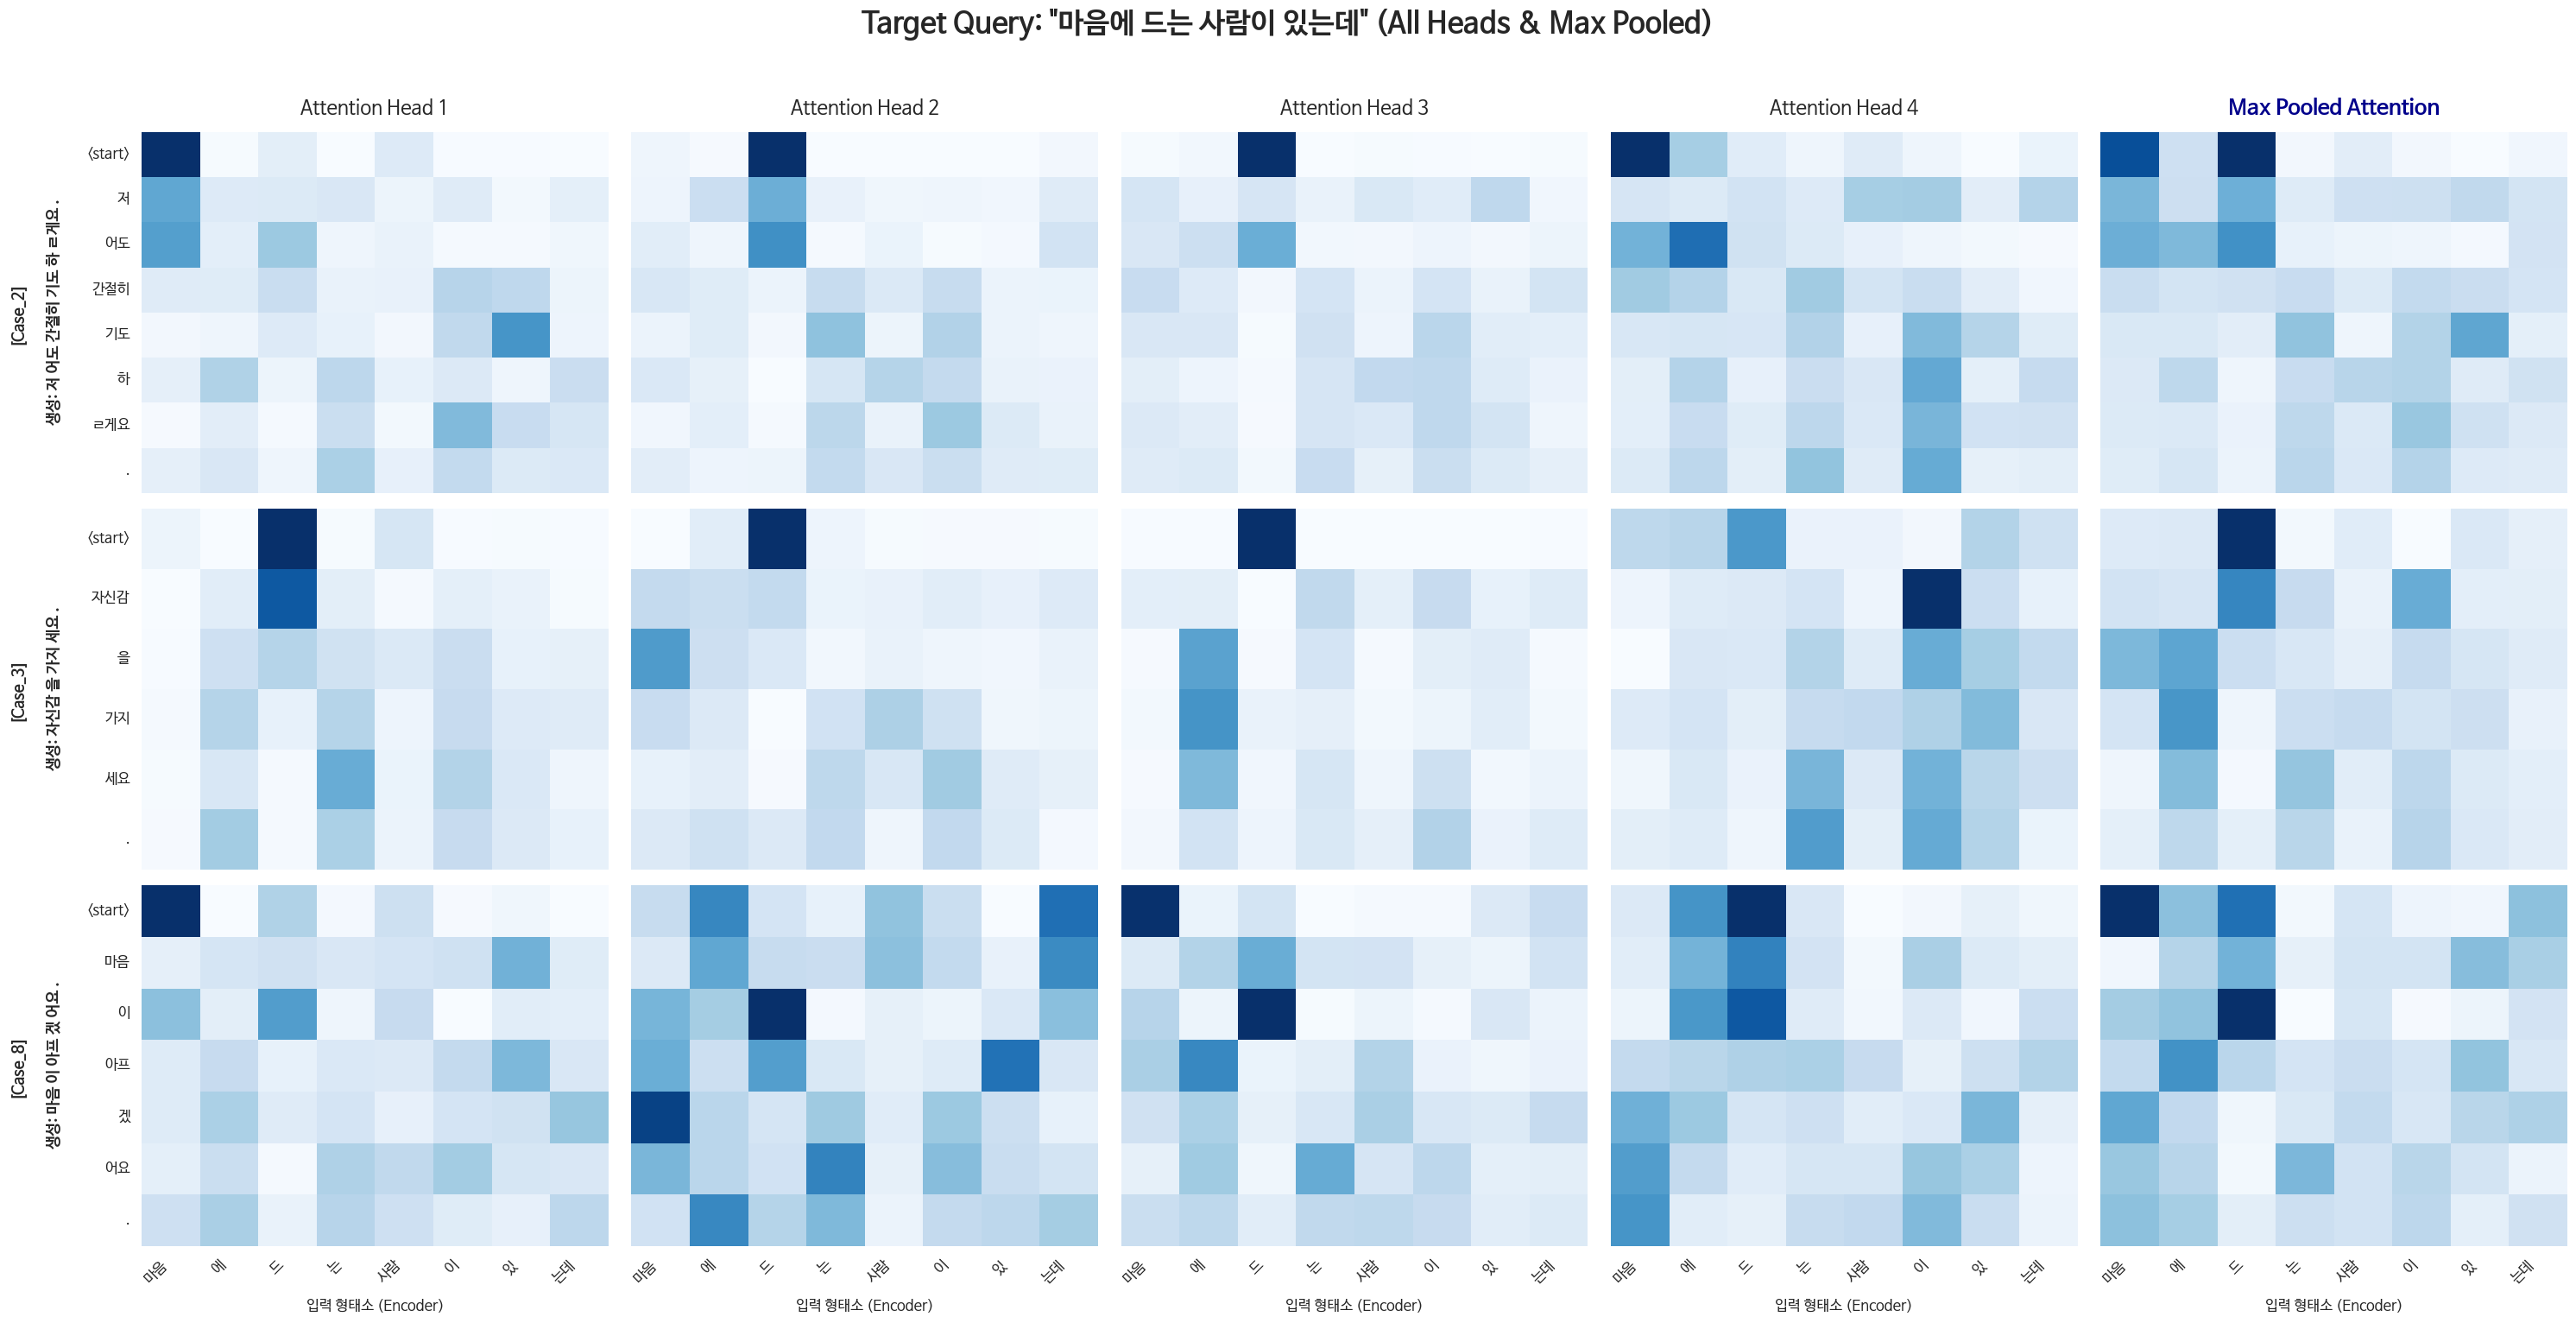


🔍 시각화 중... 타겟 질문: 항상 같이 걷던 길을 혼자 걸으니까 기분이 이상해.


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_23020\328271219.py:79: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{exp_name}_be

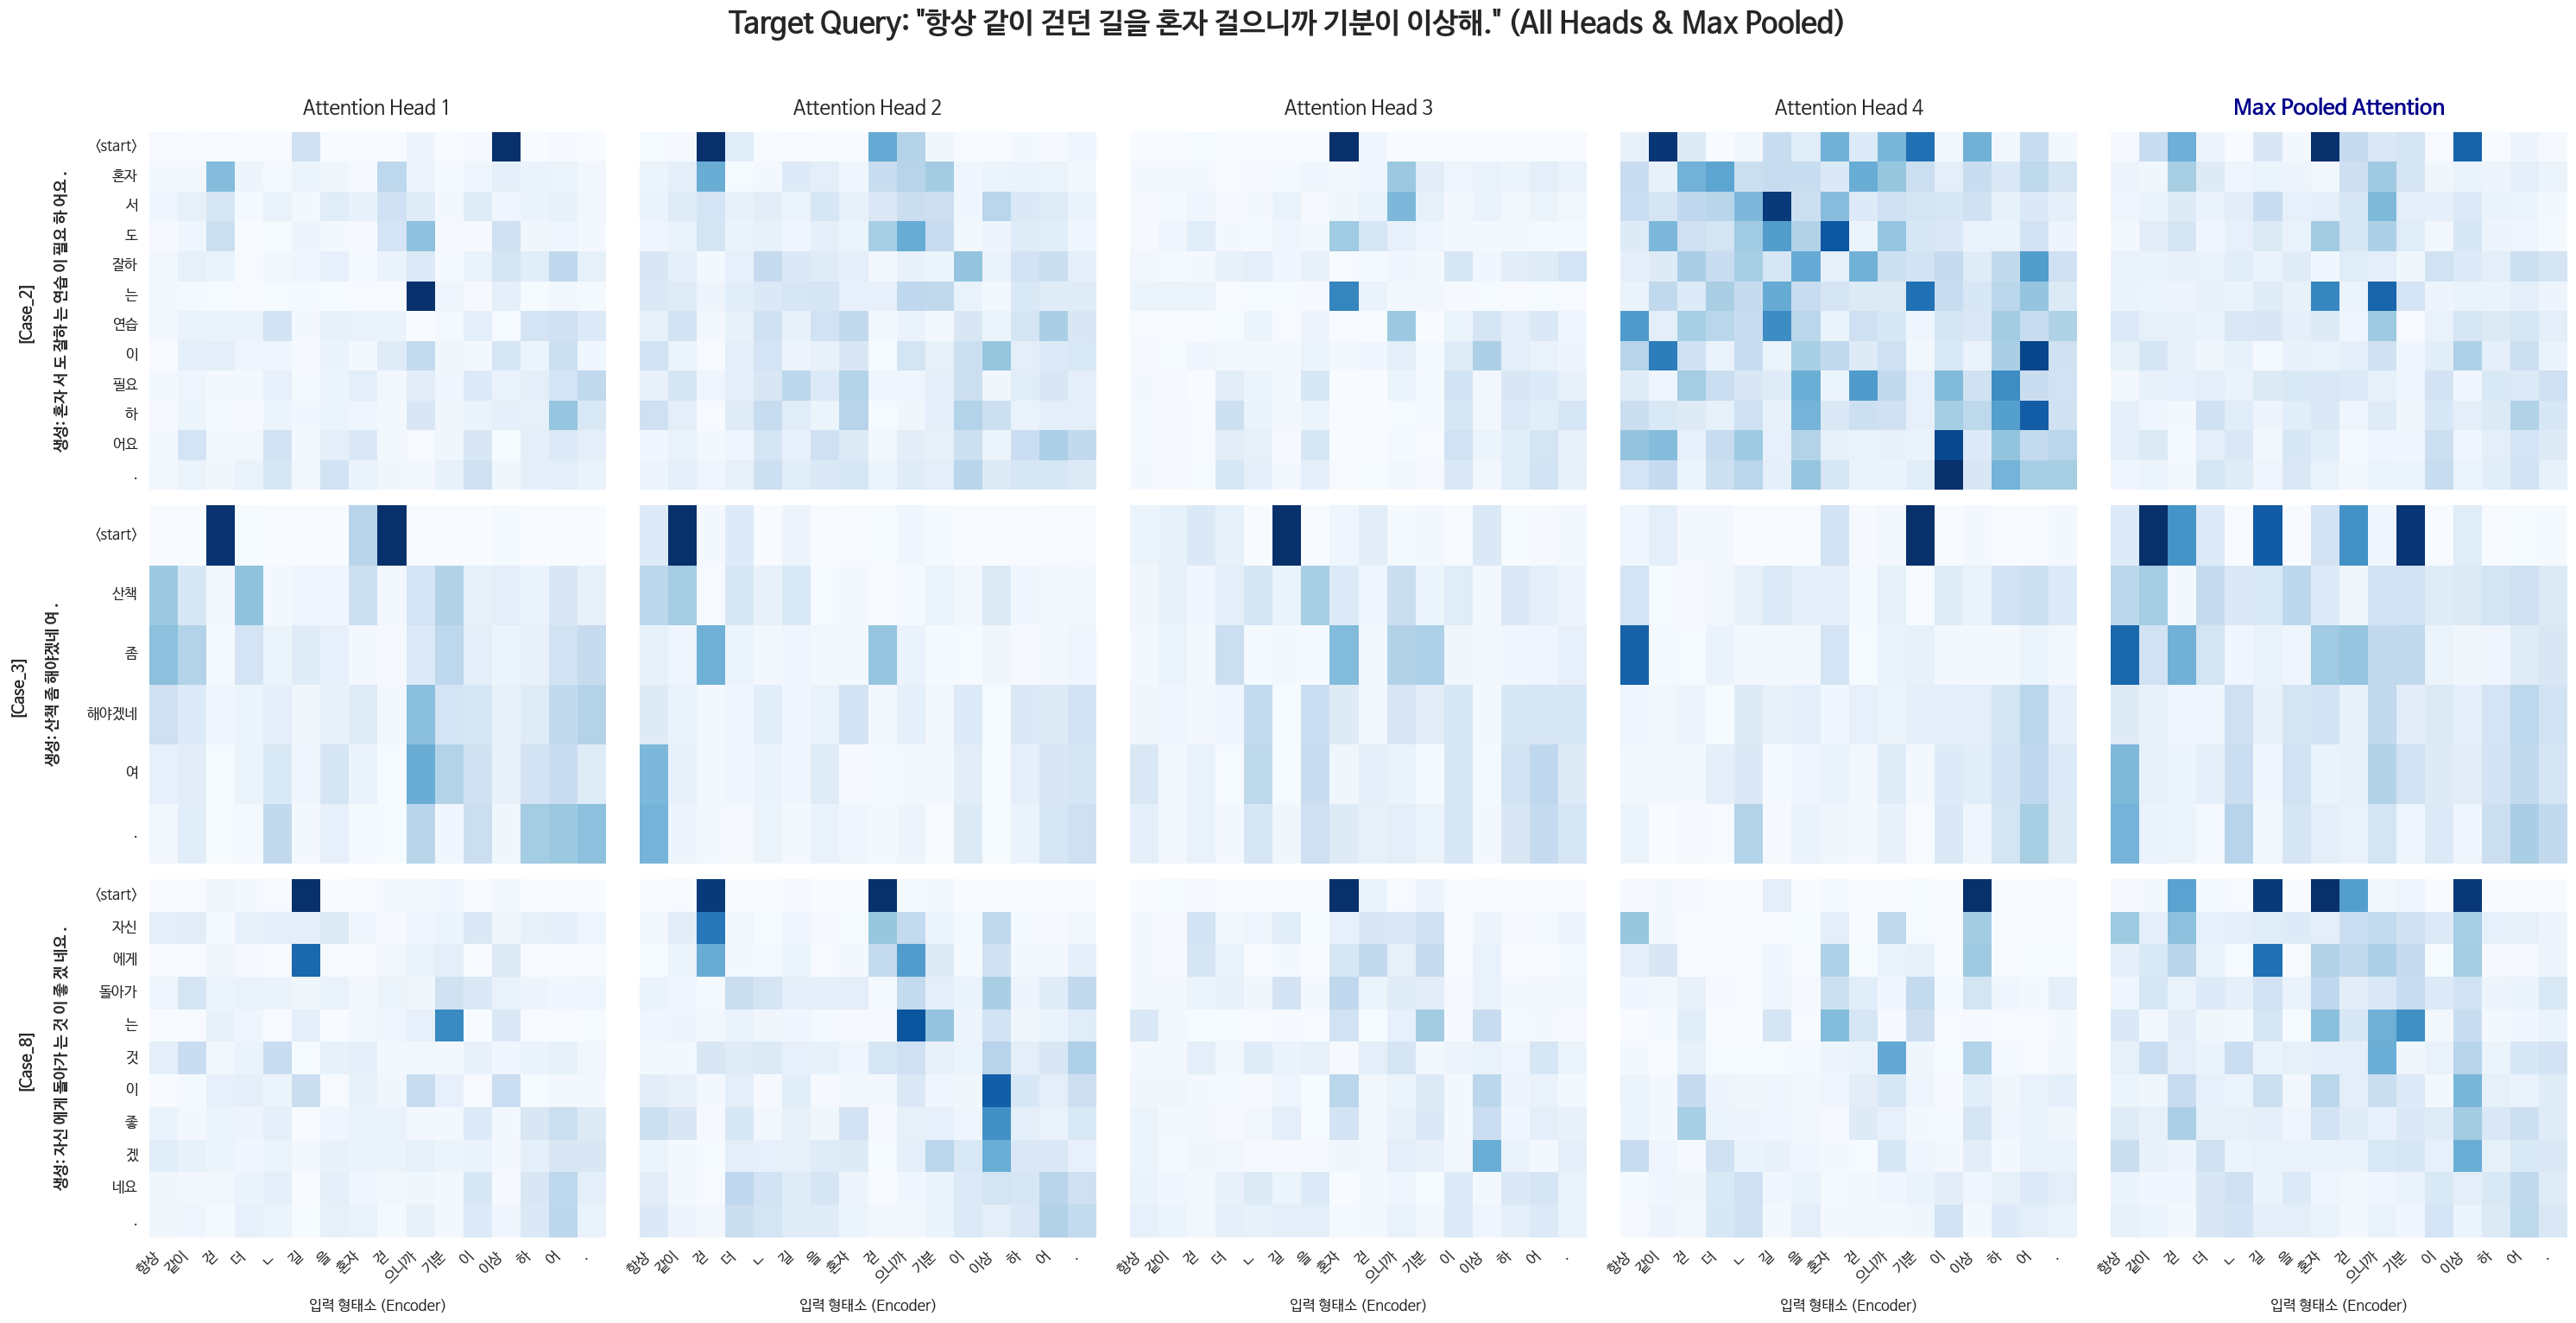


🔍 시각화 중... 타겟 질문: 내일 좋아하는 사람이랑 처음으로 단둘이 밥 먹기로 했어.


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_23020\328271219.py:79: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{exp_name}_be

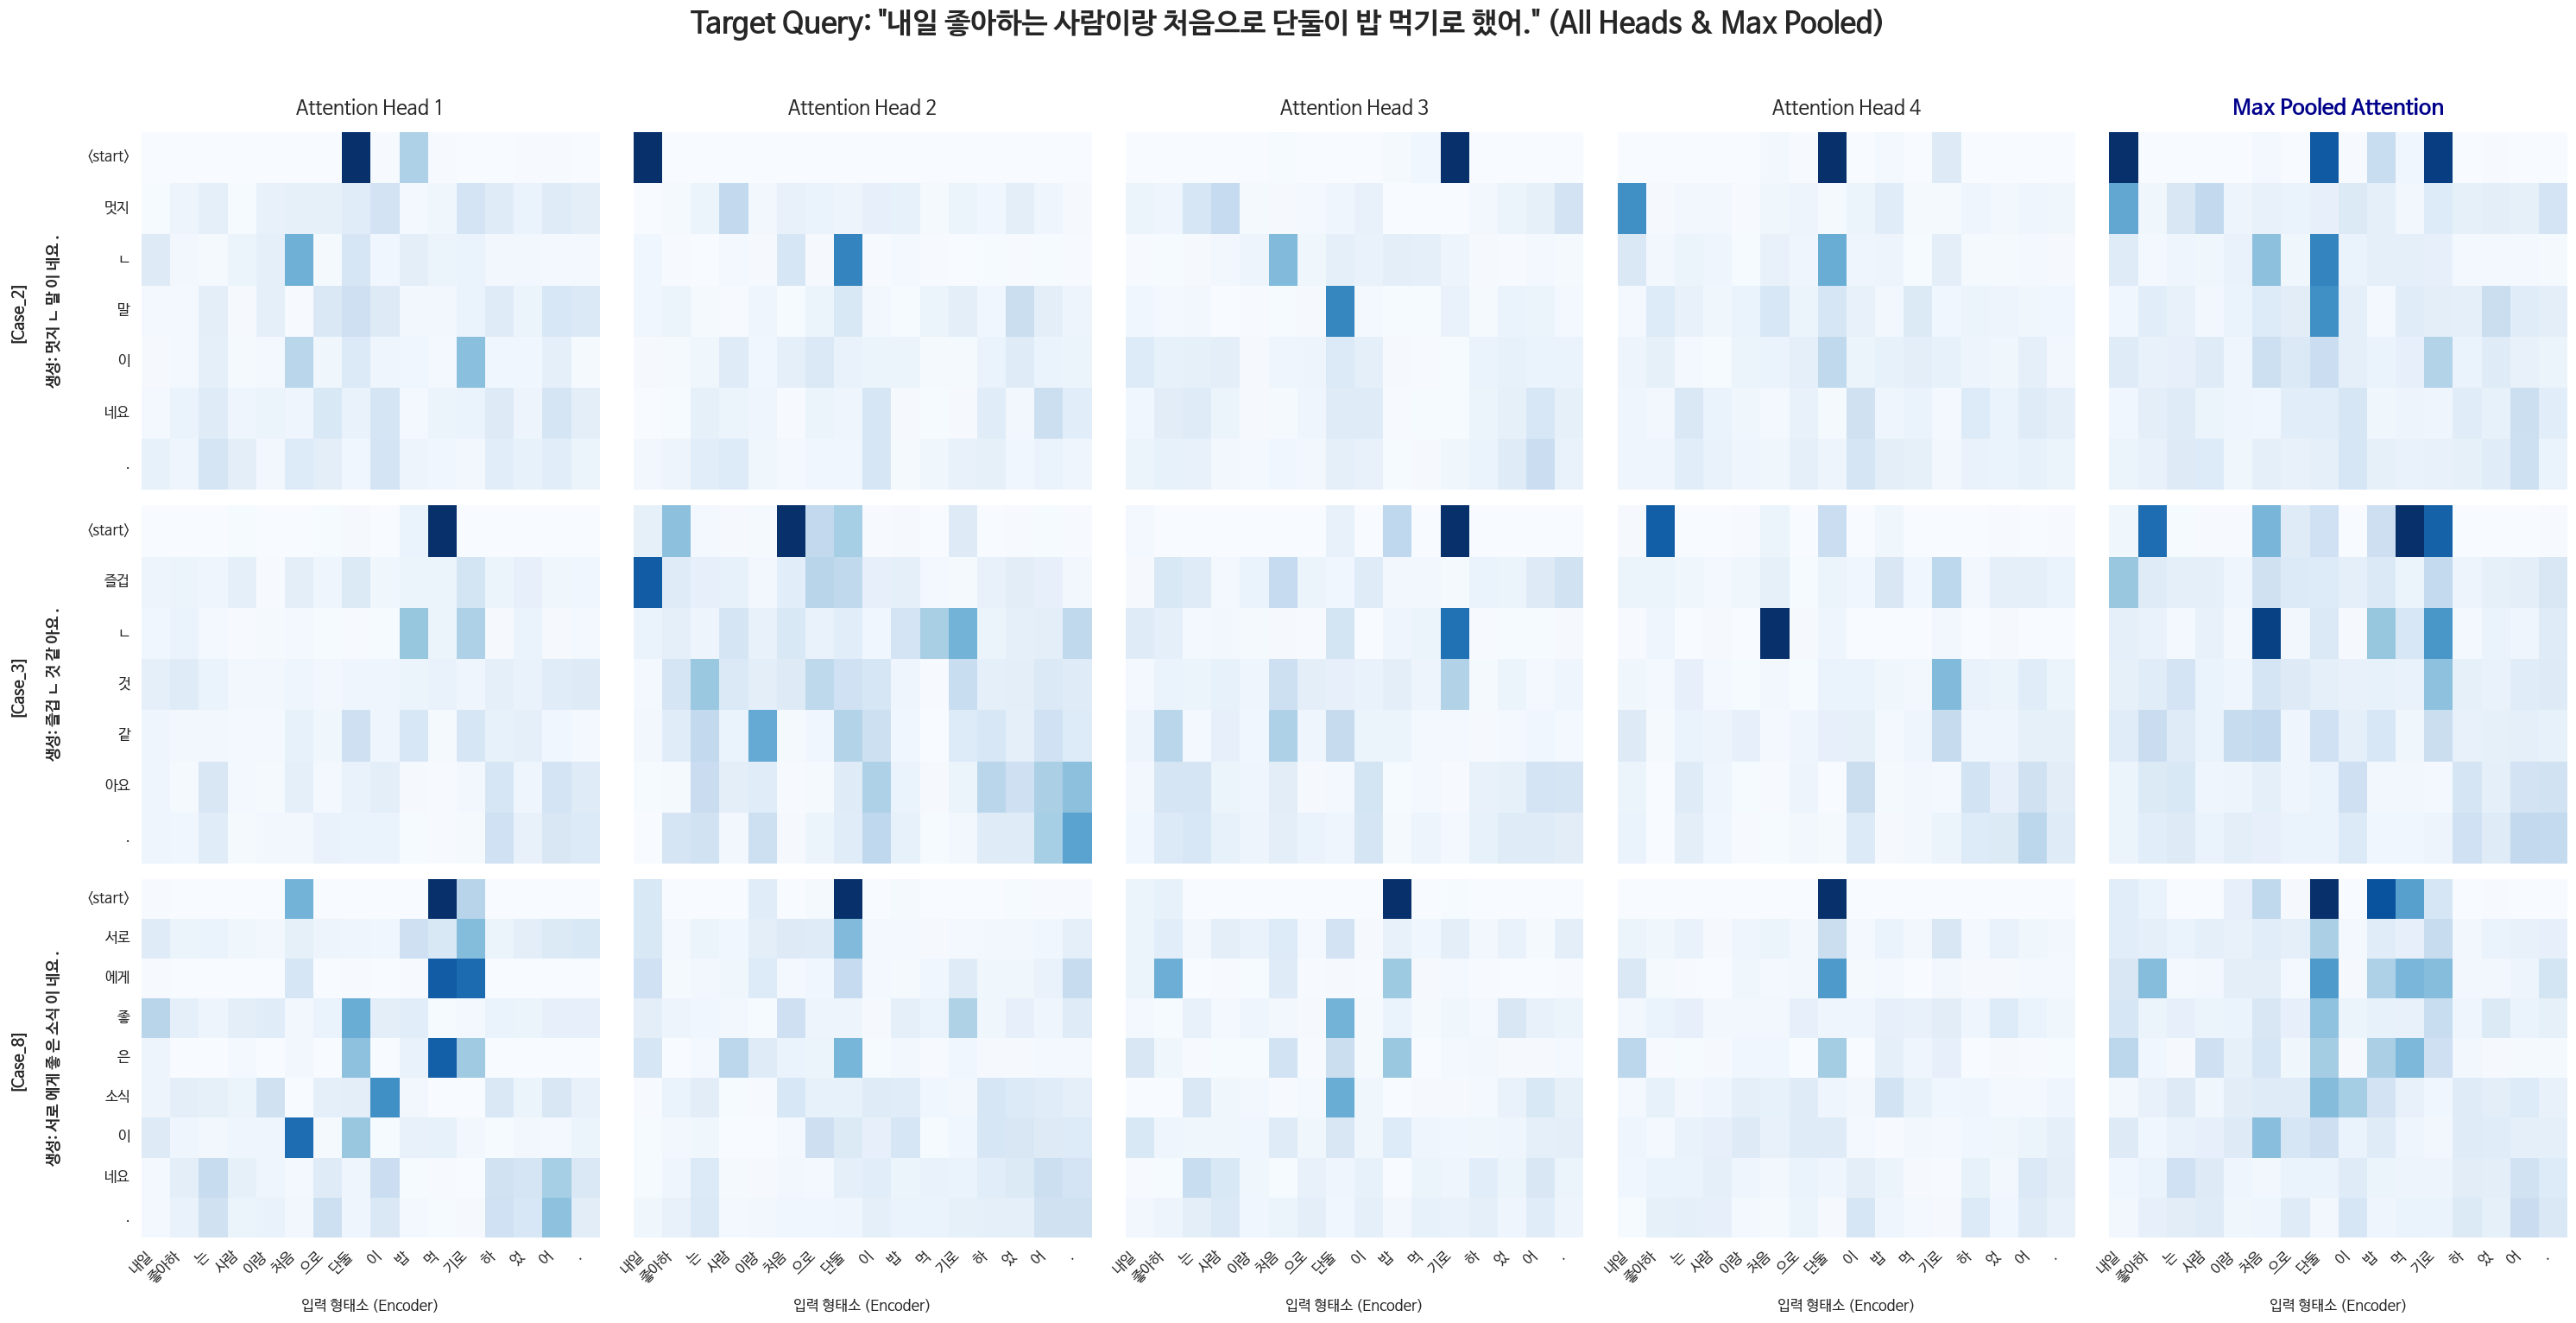

In [39]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'NanumBarunGothic' # 폰트 깨지면 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def get_forced_attention_matrices(model, src_sentence, tgt_sentence):
    model.eval()
    with torch.no_grad():
        clean_src = preprocess_sentence(src_sentence)
        src_tokens = kkma.morphs(clean_src)
        enc_in = [word2idx.get(w, word2idx['<unk>']) for w in src_tokens]
        src_tensor = torch.tensor(enc_in, dtype=torch.long, device=device).unsqueeze(0)
        
        tgt_tokens = tgt_sentence.split() 
        dec_in = [word2idx['<start>']] + [word2idx.get(w, word2idx['<unk>']) for w in tgt_tokens]
        tgt_tensor = torch.tensor(dec_in, dtype=torch.long, device=device).unsqueeze(0)
        
        enc_mask, dec_enc_mask, dec_mask = generate_masks(src_tensor, tgt_tensor)
        _, _, _, dec_enc_attns = model(src_tensor, tgt_tensor, enc_mask, dec_enc_mask, dec_mask)
        
        y_ticks = ['<start>'] + tgt_tokens
        
        # 4개의 헤드를 온전히 반환 [4, tgt_len, src_len]
        attention_matrices = dec_enc_attns[0][0].cpu().numpy()
        
        return src_tokens, y_ticks, attention_matrices

target_queries = [
    "[사랑] 마음에 드는 사람이 있는데",
    "[이별] 항상 같이 걷던 길을 혼자 걸으니까 기분이 이상해.",
    "[사랑] 내일 좋아하는 사람이랑 처음으로 단둘이 밥 먹기로 했어."
]

# 타겟 질문별 빔 서치(K=3) 정답 매핑
beam_answers = {
    target_queries[0]: [
        {"name": "Case_2", "shared": True,  "pretrain": False, "ans": "저 어도 간절히 기도 하 ㄹ게요 ."},
        {"name": "Case_3", "shared": False, "pretrain": True,  "ans": "자신감 을 가지 세요 ."},
        {"name": "Case_8", "shared": True,  "pretrain": True,  "ans": "마음 이 아프 겠 어요 ."}
    ],
    target_queries[1]: [
        {"name": "Case_2", "shared": True,  "pretrain": False, "ans": "혼자 서 도 잘하 는 연습 이 필요 하 어요 ."},
        {"name": "Case_3", "shared": False, "pretrain": True,  "ans": "산책 좀 해야겠네 여 ."},
        {"name": "Case_8", "shared": True,  "pretrain": True,  "ans": "자신 에게 돌아가 는 것 이 좋 겠 네요 ."}
    ],
    target_queries[2]: [
        {"name": "Case_2", "shared": True,  "pretrain": False, "ans": "멋지 ㄴ 말 이 네요 ."},
        {"name": "Case_3", "shared": False, "pretrain": True,  "ans": "즐겁 ㄴ 것 같 아요 ."},
        {"name": "Case_8", "shared": True,  "pretrain": True,  "ans": "서로 에게 좋 은 소식 이 네요 ."}
    ]
}

# 🌟 시각화 루프 (질문 1개당 3x5 맵 출력)
for query in target_queries:
    clean_query = query.split("] ")[1]
    print(f"\n🔍 시각화 중... 타겟 질문: {clean_query}")
    
    # 3(행) x 5(열: Head 1, 2, 3, 4 + Max Pool) 서브플롯 생성
    fig, axes = plt.subplots(3, 5, figsize=(30, 15))
    fig.suptitle(f'Target Query: "{clean_query}" (All Heads & Max Pooled)', fontsize=24, fontweight='bold', y=1.02)
    
    case_list = beam_answers[query]
    
    for row_idx, exp in enumerate(case_list):
        exp_name = exp['name']
        beam_ans = exp['ans']
        
        # 모델 빌드 및 가중치 로드
        model = build_transformer_model(
            vocab_size=vocab_size, d_model=200, n_heads=4, n_layers=1, d_ff=1024,
            dropout=0.2, pos_len=100, shared_weights=exp['shared'], 
            pretrained_matrix=embedding_matrix if exp['pretrain'] else None
        ).to(device)
        
        try:
            model.load_state_dict(torch.load(f"{exp_name}_best.pt"))
        except:
            model.load_state_dict(torch.load(f"models/{exp_name}_best.pt"))
            
        src_words, tgt_words, attention_matrices = get_forced_attention_matrices(model, clean_query, beam_ans)
        
        # 5개 열 그리기 루프
        for col_idx in range(5):
            ax = axes[row_idx, col_idx]
            
            # 0~3열은 개별 헤드, 4열은 4개 헤드의 최댓값(Max Pooling)
            if col_idx < 4:
                plot_matrix = attention_matrices[col_idx]
                title_text = f"Attention Head {col_idx + 1}"
            else:
                plot_matrix = attention_matrices.max(axis=0) 
                title_text = "Max Pooled Attention"
            
            sns.heatmap(plot_matrix, cmap='Blues', cbar=False, ax=ax)
            
            # X축 라벨
            ax.set_xticks(np.arange(len(src_words)) + 0.5)
            if row_idx == 2:
                ax.set_xticklabels(src_words, rotation=45, ha='right', fontsize=12)
                ax.set_xlabel('입력 형태소 (Encoder)', fontsize=12, labelpad=10)
            else:
                ax.set_xticklabels([])
                
            # Y축 라벨
            ax.set_yticks(np.arange(len(tgt_words)) + 0.5)
            if col_idx == 0:
                ax.set_yticklabels(tgt_words, rotation=0, fontsize=12)
                ax.set_ylabel(f"[{exp_name}]\n\n생성: {beam_ans}", fontsize=13, fontweight='bold', labelpad=20)
            else:
                ax.set_yticklabels([])
            
            # 타이틀 세팅 (Max Pooled 열은 굵고 진하게 표시)
            if row_idx == 0:
                if col_idx == 4:
                    ax.set_title(title_text, fontsize=18, fontweight='bold', color='darkblue', pad=15)
                else:
                    ax.set_title(title_text, fontsize=16, pad=15)
                
        # 메모리 정리
        del model
        torch.cuda.empty_cache()
        
    plt.tight_layout()
    plt.show()


### [Chapter 7-6] 크로스 어텐션 맵(Cross-Attention Map) 시각화 및 고찰

정성평가에서 나타난 모델별 생성 결과의 차이를 원인 수준에서 분석하기 위해, 디코더가 문장을 생성할 때 인코더의 입력 토큰을 참조하는 크로스 어텐션 맵을 시각화하였다. 분석의 가독성을 높이기 위해 4개 헤드(Multi-Head)의 최댓값(Max Pooling)을 추출하여 모델이 가장 강하게 참조한 토큰을 식별하였다.

#### 1. 1-Layer 트랜스포머 아키텍처의 구조적 한계 (노이즈 패턴)
시각화 결과, 기계 번역 태스크에서 주로 관찰되는 명확한 대각선(Diagonal) 형태의 동적 매핑은 나타나지 않았으며, 1층 구조 및 소규모 데이터셋에 기인한 구조적 노이즈가 공통으로 관찰되었다.

* **어텐션 싱크(Attention Sink) 현상:** 모든 모델에서 디코더가 다음 단어를 예측할 때 `<start>` 토큰이나 마침표(`.`), 혹은 무의미한 형식 형태소(예: '는', '이')에 어텐션 가중치가 과도하게 집중되는 현상이 확인되었다. 이는 Softmax 연산의 수학적 특성(확률 총합=1)으로 인해 특별히 참조할 문맥이 없을 때 특정 토큰을 쓰레기통(No-Op Buffer)으로 활용하는 전형적인 패턴이다. 특히 본 연구의 모델은 1층 구조로 설계되어, 다층(Multi-layer) 모델처럼 후속 레이어에서 이러한 싱크 노이즈를 정제하거나 상쇄하지 못하고 디코딩 표면에 그대로 노출된 것으로 분석된다.

* **세로줄 밴딩(Vertical Banding):** 디코딩 스텝이 진행되는 동안 문맥의 흐름에 따라 어텐션이 동적으로 이동하지 않고, 입력 문장의 특정 1~2개 토큰에 가중치가 고정되는 정적 어텐션(Static Attention) 현상이 두드러졌다. 이는 1-Layer 모델이 가진 파라미터 용량(Capacity)의 한계와 소규모 데이터셋 환경으로 인해, 모델이 문장 전체의 시퀀스를 정렬하기보다 특정 핵심 키워드에 의존하여 매핑을 수행하는 과적합 성향을 보이기 때문으로 해석된다.

#### 2. 모델별 어텐션 매핑 특징 및 성능 분석
이러한 구조적 노이즈 속에서도, 실험 통제 조건(사전학습 유무, 가중치 공유 등)에 따라 유의미한 시맨틱 매핑(Semantic Mapping)의 차이가 확인되었다.

**① Case 3 (Pretrained + Individual): 사전학습 임베딩 기반의 어휘적 연관성**
* **특징:** 외부 코퍼스로 학습된 `ko.bin`의 영향으로, 단어 간의 범용적 유의어 관계가 어텐션에 강하게 투영되었다.
* **분석:** "[사랑] 내일... 단둘이 밥 먹기로 했어" 쿼리에서 '단둘', '밥', '먹' 토큰을 참조하여 '즐겁다'라는 감정 상태를 도출하는 긍정적 결과를 보였다. 그러나 "[이별] 항상 같이 걷던 길을 혼자 걸으니까..." 쿼리에서는 '혼자'라는 상황적 맥락을 배제하고 '걷(다)', '길' 토큰에만 가중치를 부여하여 "산책 좀 해야겠네여"라는 상황에 부합하지 않는 출력을 생성하는 키워드 편향성 한계를 노출했다.

**② Case 8 (Pretrained + Shared + Aug): 데이터 증강 병합 시의 상황 추론 및 노이즈**
* **특징:** 증강 데이터에 의한 노이즈 혼입으로 조사 과적합 현상이 가장 심하게 관찰되었으나, 일부 상황에서 고도의 추론 매핑을 보였다.
* **분석:** "내일... 단둘이 밥 먹기로 했어" 쿼리에서 '단둘', '먹' 토큰에 집중하여 "서로에게 좋은 소식이네요"라는 문장을 생성하였다. 이는 단순 키워드 매칭을 넘어 상황(단둘이 식사)을 개념(좋은 소식)으로 추상화한 유의미한 성과다. 그러나 "[사랑] 마음에 드는 사람이 있는데" 쿼리에서는 '사람' 토큰을 참조하지 못하고 '마음' 토큰에만 밴딩되어 "마음이 아프겠어요"를 출력하는 등 생성 품질의 편차가 컸다.

**③ Case 2 (Scratch + Shared): 도메인 특화 감정 매핑 (Best Model)**
* **특징:** 구조적 한계인 세로줄 밴딩 현상은 동일하게 발생하였으나, 밴딩의 타겟이 물리적 행동을 나타내는 단어가 아닌 감정 및 상황 단어에 집중되었다.
* **분석:** "[이별] 항상 같이 걷던 길을 혼자 걸으니까..." 쿼리에서 물리적 키워드('걷다', '길')를 참조한 Case 3과 달리, '혼자', '기분', '이상' 토큰에 어텐션을 집중시켜 "혼자서도 잘하는 연습이 필요해요"라는 적절한 응답을 생성하였다. 

#### 3. 결론
크로스 어텐션 맵 분석 결과, 사전학습 임베딩을 적용한 모델(Case 3, Case 8)은 일반적인 어휘 연관성 파악에 강점을 보였으나, 대화 도메인의 복잡한 감정선을 처리하는 과정에서 단순 키워드 매칭의 오류를 범하는 경향이 관찰되었다. 반면, **Scratch 임베딩과 가중치 공유(Weight Tying)를 결합한 Case 2**는 1.1만 개의 소규모 데이터셋 환경에서도 대화 텍스트 고유의 감정 및 문맥 분포를 가장 안정적으로 학습하여, 정량적/정성적 지표 모두에서 가장 우수한 아키텍처 구성임을 교차 검증하였다.


### [Chapter 8] 프로젝트 총평 및 결론

본 프로젝트는 약 1.1만 개의 소규모 일상 대화 데이터를 활용하여 트랜스포머 기반의 한국어 챗봇을 구현하고, 다양한 조건에 따른 성능 변화를 관찰하고자 진행되었다. 전체적인 프로젝트의 과정과 결론은 다음과 같다.

**1. 소규모 데이터에 맞춘 모델 구조 간소화**
데이터 셋의 규모가 작기 때문에, 모델이 지나치게 복잡하면 과적합(Overfitting)이 발생할 것이라 판단했다. 별도의 튜닝 실험을 거치지는 않았으나, 논리적인 추론을 바탕으로 트랜스포머의 구조를 1-Layer, 4-Heads, d_model=200 수준으로 대폭 줄여 나름의 최적점을 찾아보고자 하였다.

**2. 아블레이션 스터디를 통한 구성 요소 비교**
임베딩 방식(Scratch vs Pretrained), 가중치 공유(Weight Tying), 데이터 증강 유무를 변인으로 총 8가지 형태의 모델을 학습시켜 보았다. 
실험 결과, 외부 사전학습 임베딩이나 임의의 데이터 증강 기법을 도입했을 때 오히려 대화 도메인의 문맥과 맞지 않는 노이즈가 유입되는 현상이 있었다. 결과적으로 주어진 대화 데이터에만 맞추어 처음부터 학습시키고 가중치를 공유한 모델(Case 2)이 상대적으로 가장 자연스러운 답변을 생성하는 경향을 보였다.

**3. 어텐션 맵 분석을 통해 확인한 모델의 한계**
생성 결과를 어텐션 맵으로 시각화하여 분석해 본 결과, 본 모델의 구조적 한계가 뚜렷하게 나타났다. 1층 모델이라는 한계로 인해 디코더가 무의미한 토큰에 집중하는 어텐션 싱크(Attention Sink) 현상이나, 문맥에 따라 유연하게 어텐션이 이동하지 못하고 1~2개 키워드에만 고정되는 정적 밴딩(Vertical Banding) 현상이 다수 관찰되었다. 문장 전체를 깊이 있게 추론하기보다는, 단어 간의 얕은 연관성에 의존해 대답을 조립하는 수준에 머물러 있었다.

**4. 종합 결론**
결론적으로 이번 프로젝트에서 학습시킨 모델은 크로스 어텐션의 흐름이나 구조적 관점에서 볼 때 완전히 잘 만들어진 모델이라고 보기는 어렵다. 하지만 제한된 소규모 데이터셋 환경에서 무작정 모델의 크기를 키우기보다는, 직관에 따라 파라미터를 조절해 보고 아블레이션 스터디를 통해 여러 조합을 비교해 보는 과정을 거쳤다. 비록 한계는 명확하지만, 이러한 시도를 통해 소규모 데이터 환경에서도 어느 정도 그럴듯한(Plausible) 대답을 뱉어내는 모델을 만들어 볼 수 있었다는 점에 이번 프로젝트의 의의를 두고자 한다.


# 프로젝트 회고  

* 사전 학습된 임베딩이나 가중치 공유 기법이 각각 모델 성능 향상에는 긍정적인 영향을 주었지만, 두 개가 합쳐졌을 때는 오히려 부작용이 발생한다는 것을 아블레이션 스터디를 통해 알게 되었습니다. 이를 통해 무작정 아키텍처나 기법을 쌓아 올리는 것만이 능사는 아니라는 점을 깨달았습니다.

* 데이터 증강이 오히려 모델 성능을 떨어뜨리는 현상을 관찰했는데, 이는 유의어 교체 증강 방식의 맹점(예: '날씨' $\rightarrow$ '겨울철'로 교체되며 문맥 훼손)에 원인이 있었을 것으로 판단됩니다. 데이터 증강은 한정된 데이터셋 환경에서 정말 중요한 기법이지만, 태스크의 목적과 증강 방식을 충분히 이해하지 못하고 잘못 설계했을 때는 심각한 부작용이 생길 수 있다는 것을 배울 수 있었습니다.

* 이번 프로젝트에서는 다행히 모델이 어느 정도 그럴듯한 답변을 내놓아 주어서, 일반적인 정성평가는 앞선 프로젝트들보다 훨씬 수월하게 진행할 수 있었습니다. 그리고 어텐션 맵을 분석하는 과정에서, 모델이 겉보기에는 괜찮은 답변을 내놓고 있지만 문맥을 완전히 파악했다기보다는 얕은 키워드 매칭에 의존하고 있다는 점을 확인하면서 어텐션 맵 분석의 중요성을 다시 한번 실감했습니다. 과적합을 피하기 위해 트랜스포머를 1층만 쌓은 부작용일 수도 있지만, 그렇다고 두 개 이상의 층을 쌓았으면 훈련 데이터셋에만 강하게 과적합된 모델이 나왔을 수도 있을 것 같아서,  데이터셋에 맞는 최적의 아키텍처에 대해 한번 더 고민해 보는 계기가 되었습니다.

* 어텐션 맵을 그리고 분석하는 과정에서, 어떤 문장을 고르고 어떤 식으로 맵을 보여줄지 등 가독성에 대한 고민을 많이 했던 것 같습니다. 이번에는 최대한 많은 정보를 담고 싶어서 하나의 질문에 대해 3개의 모델을 뽑고 3x5 구조(4개 헤드 + Max Pooling)로 시각화했는데, 15개의 그래프가 한 장에 담기다 보니 가독성이 꽤 많이 떨어지는 아쉬움이 있었습니다. 다음 프로젝트에서는 선택과 집중을 통해 좀 더 유의미한 질문 텍스트와 어텐션 맵 쌍을 잘 선별하여, 가독성과 의미를 모두 챙기는 정성 분석을 해봐야겠다고 생각했습니다.
